# NBA Point-Differential Prediction
**CSE 493G1 Research Project**

This notebook predicts NBA game point differentials and compares model performance across four levels of data granularity:
- Level 1: Season-level team aggregates (coarsest)
- Level 2: Game-level team rolling averages
- Level 3: Player-level box scores
- Level 4: Possession-level play-by-play (finest)

Three model families are trained on each: Ridge Regression, XGBoost, and a fully connected neural network.

## 1. Setup & Installs

In [12]:
# Install dependencies if needed
!pip install pandas numpy scikit-learn xgboost torch nba_api matplotlib seaborn tqdm

In [13]:
%pip install numpy pandas matplotlib seaborn scikit-learn xgboost torch nba_api tqdm IProgress

Note: you may need to restart the kernel to use updated packages.


In [14]:
import os
import time
import json
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from tqdm.auto import tqdm  # uses notebook if available, else terminal bar
except Exception:
    from tqdm import tqdm       # hard fallback

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score

from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from nba_api.stats.endpoints import (
    LeagueDashTeamStats,
    LeagueGameFinder,
    TeamGameLog,
    PlayerGameLog,
    LeagueDashPlayerStats,
    PlayByPlayV2,
)
from nba_api.stats.static import teams as nba_teams_static

warnings.filterwarnings('ignore')

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Directory setup ---
DIRS = ['data/raw', 'data/processed', 'models', 'results']
for d in DIRS:
    os.makedirs(d, exist_ok=True)

# --- Seasons ---
# NBA season IDs: '2015-16', ..., '2024-25'
ALL_SEASONS = [f"{y}-{str(y+1)[-2:]}" for y in range(2015, 2025)]
TRAIN_SEASONS = [s for s in ALL_SEASONS if int(s[:4]) <= 2022]   # 2015-16 to 2022-23
VAL_SEASONS   = [s for s in ALL_SEASONS if int(s[:4]) == 2023]   # 2023-24
TEST_SEASONS  = [s for s in ALL_SEASONS if int(s[:4]) == 2024]   # 2024-25

print("All seasons :", ALL_SEASONS)
print("Train seasons:", TRAIN_SEASONS)
print("Val seasons  :", VAL_SEASONS)
print("Test seasons :", TEST_SEASONS)
print(f"PyTorch device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

All seasons : ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
Train seasons: ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
Val seasons  : ['2023-24']
Test seasons : ['2024-25']
PyTorch device: cuda


## 2. Data Collection

### Level 1 — Season-Level Team Aggregates (Coarsest)

For each season and each game, the feature vector consists of **both teams' cumulative season stats up to (but not including) that game**. We use `LeagueDashTeamStats` per season and `LeagueGameFinder` to get the game schedule with scores.

**Features per team:** W_PCT, PTS (PPG), OPP_PTS (OPPG), OFF_RATING, DEF_RATING, NET_RATING, PACE, EFG_PCT, TM_TOV_PCT, OREB_PCT, FTA_RATE, plus GP (games played).

**Target:** home score − away score (point differential).

In [15]:
# ── Helpers ────────────────────────────────────────────────────────────────────

def cache_path(filename: str) -> str:
    return os.path.join('data/raw', filename)


def load_or_fetch(filename: str, fetch_fn, **fetch_kwargs) -> pd.DataFrame:
    """Load a CSV from cache, or call fetch_fn and save it."""
    path = cache_path(filename)
    if os.path.exists(path):
        return pd.read_csv(path)
    df = fetch_fn(**fetch_kwargs)
    df.to_csv(path, index=False)
    return df


def fetch_season_team_stats(season: str) -> pd.DataFrame:
    """Pull full-season team stats for a given season string (e.g. '2022-23')."""
    time.sleep(1)
    endpoint = LeagueDashTeamStats(
        season=season,
        season_type_all_star='Regular Season',
        measure_type_detailed_defense='Base',
        per_mode_detailed='PerGame', # origiinally per_mode_simple
    )
    df = endpoint.get_data_frames()[0]
    df['SEASON'] = season
    return df


def fetch_season_team_stats_advanced(season: str) -> pd.DataFrame:
    """Pull advanced team stats (ratings, pace, etc.) for a given season."""
    time.sleep(1)
    endpoint = LeagueDashTeamStats(
        season=season,
        season_type_all_star='Regular Season',
        measure_type_detailed_defense='Advanced',
        per_mode_detailed='PerGame',
    )
    df = endpoint.get_data_frames()[0]
    df['SEASON'] = season
    return df


def fetch_season_games(season: str) -> pd.DataFrame:
    """Pull all regular-season games for a given season."""
    time.sleep(1)
    finder = LeagueGameFinder(
        season_nullable=season,
        season_type_nullable='Regular Season',
        league_id_nullable='00',
    )
    df = finder.get_data_frames()[0]
    df['SEASON'] = season
    return df

In [16]:
# ── Pull & cache season stats + game logs ──────────────────────────────────────

all_base_stats = []
all_adv_stats  = []
all_games      = []

for season in tqdm(ALL_SEASONS, desc='Pulling season data'):
    # Base (per-game) stats
    base = load_or_fetch(
        f'team_stats_base_{season}.csv',
        fetch_season_team_stats,
        season=season,
    )
    all_base_stats.append(base)

    # Advanced stats
    adv = load_or_fetch(
        f'team_stats_adv_{season}.csv',
        fetch_season_team_stats_advanced,
        season=season,
    )
    all_adv_stats.append(adv)

    # Game-level results
    games = load_or_fetch(
        f'games_{season}.csv',
        fetch_season_games,
        season=season,
    )
    all_games.append(games)

df_base  = pd.concat(all_base_stats, ignore_index=True)
df_adv   = pd.concat(all_adv_stats,  ignore_index=True)
df_games = pd.concat(all_games,      ignore_index=True)

print(f'Base stats shape : {df_base.shape}')
print(f'Adv  stats shape : {df_adv.shape}')
print(f'Games      shape : {df_games.shape}')
print('\nBase stat columns:', df_base.columns.tolist())
print('\nAdv  stat columns:', df_adv.columns.tolist())
print('\nGames      columns:', df_games.columns.tolist())

Pulling season data:   0%|          | 0/10 [00:00<?, ?it/s]

Base stats shape : (300, 55)
Adv  stats shape : (300, 47)
Games      shape : (23958, 29)

Base stat columns: ['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'SEASON']

Adv  stat columns: ['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'E_OFF_RATING', 'OFF_RATING', 'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'E_PACE', 'PACE', 'PACE_PER40', 'POSS', 'PIE', 'GP_RANK

In [17]:
import ipywidgets
print(ipywidgets.__version__)

8.1.8


In [18]:
# ── Build per-game rolling season-aggregate features ──────────────────────────
#
# Strategy:
#   LeagueGameFinder returns one row per team per game, including PTS scored.
#   We pair home vs. away rows by GAME_ID, then for each team compute a rolling
#   cumulative season average of key box-score stats *before* that game.
#   We then merge the end-of-season advanced stats (ratings, pace, etc.) as a
#   proxy for season-level quality — note this uses the *final* season value,
#   which we scale by GP fraction to approximate the pre-game season average.
#
#   A cleaner rolling approach (using per-game team logs) is used in Level 2;
#   for Level 1 we keep it season-aggregate as specified.

# Column subsets
BASE_KEEP = ['TEAM_ID', 'TEAM_NAME', 'SEASON', 'GP', 'W_PCT',
             'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'FG_PCT', 'FG3_PCT', 'FT_PCT']
ADV_KEEP  = ['TEAM_ID', 'SEASON', 'OFF_RATING', 'DEF_RATING', 'NET_RATING',
             'PACE', 'EFG_PCT', 'TM_TOV_PCT', 'OREB_PCT', 'FTA_RATE']

# Keep only available columns
base_cols = [c for c in BASE_KEEP if c in df_base.columns]
adv_cols  = [c for c in ADV_KEEP  if c in df_adv.columns]

df_base_slim = df_base[base_cols].copy()
df_adv_slim  = df_adv[adv_cols].copy()

# Merge base + advanced into one season-level stats table
df_season_stats = df_base_slim.merge(df_adv_slim, on=['TEAM_ID', 'SEASON'], how='left')
print(df_season_stats.shape)
df_season_stats.head(3)

(300, 21)


,TEAM_ID,TEAM_NAME,SEASON,GP,W_PCT,PTS,REB,AST,STL,BLK,...,FG_PCT,FG3_PCT,FT_PCT,OFF_RATING,DEF_RATING,NET_RATING,PACE,EFG_PCT,TM_TOV_PCT,OREB_PCT
0,1610612737,Atlanta Hawks,2015-16,82,0.585,102.8,42.1,25.6,9.1,5.9,...,0.458,0.350,0.783,104.6,100.8,3.9,97.63,0.516,0.152,0.234
1,1610612738,Boston Celtics,2015-16,82,0.585,105.7,44.9,24.2,9.2,4.2,...,0.439,0.335,0.788,105.8,102.5,3.3,99.43,0.488,0.138,0.290
2,1610612751,Brooklyn Nets,2015-16,82,0.256,98.6,42.4,22.3,7.6,4.0,...,0.453,0.352,0.757,102.4,109.7,-7.4,96.12,0.492,0.153,0.279


In [19]:
# ── Parse game log and pair home vs. away ──────────────────────────────────────

# LeagueGameFinder returns one row per team per game.
# MATCHUP column looks like 'BOS vs. MIA' (home) or 'BOS @ MIA' (away).
# We use the '@' to detect away games.

df_g = df_games.copy()
df_g['GAME_DATE'] = pd.to_datetime(df_g['GAME_DATE'])
df_g['IS_HOME']   = ~df_g['MATCHUP'].str.contains('@')

# Sort so we can compute rolling cumsum per team per season
df_g = df_g.sort_values(['SEASON', 'TEAM_ID', 'GAME_DATE']).reset_index(drop=True)

# Keep the columns we need
GAME_COLS = ['GAME_ID', 'GAME_DATE', 'SEASON', 'TEAM_ID', 'TEAM_NAME',
             'IS_HOME', 'PTS', 'PLUS_MINUS']
game_cols_avail = [c for c in GAME_COLS if c in df_g.columns]
df_g = df_g[game_cols_avail].copy()

print(df_g.shape)
df_g.head(4)

(23958, 8)


,GAME_ID,GAME_DATE,SEASON,TEAM_ID,TEAM_NAME,IS_HOME,PTS,PLUS_MINUS
0,21500001,2015-10-27,2015-16,1610612737,Atlanta Hawks,True,94,-12.0
1,21500019,2015-10-29,2015-16,1610612737,Atlanta Hawks,False,112,11.0
2,21500026,2015-10-30,2015-16,1610612737,Atlanta Hawks,True,97,3.0
3,21500039,2015-11-01,2015-16,1610612737,Atlanta Hawks,False,94,2.0


In [20]:
# ── Pair home and away for each game ──────────────────────────────────────────

# Each GAME_ID appears twice (once per team). We pair them to get one row per game
# with home_team_id, home_pts, away_team_id, away_pts.

if 'IS_HOME' in df_g.columns:
    home_df = df_g[df_g['IS_HOME']].rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID', 'TEAM_NAME': 'HOME_TEAM_NAME',
        'PTS': 'HOME_PTS', 'PLUS_MINUS': 'HOME_PLUS_MINUS'
    }).drop(columns=['IS_HOME'])

    away_df = df_g[~df_g['IS_HOME']].rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID', 'TEAM_NAME': 'AWAY_TEAM_NAME',
        'PTS': 'AWAY_PTS', 'PLUS_MINUS': 'AWAY_PLUS_MINUS'
    }).drop(columns=['IS_HOME'])

    df_paired = home_df.merge(
        away_df[['GAME_ID', 'SEASON', 'AWAY_TEAM_ID', 'AWAY_TEAM_NAME', 'AWAY_PTS']],
        on=['GAME_ID', 'SEASON'],
        how='inner'
    )
else:
    # Fallback: derive from PLUS_MINUS — home team has positive PLUS_MINUS when they win.
    # Instead use MATCHUP string parsing.
    raise RuntimeError("IS_HOME column missing — check MATCHUP parsing.")

# Target: home − away point differential
df_paired['POINT_DIFF'] = df_paired['HOME_PTS'] - df_paired['AWAY_PTS']

# Drop games where scores are missing
df_paired = df_paired.dropna(subset=['HOME_PTS', 'AWAY_PTS'])

print(df_paired.shape)
df_paired.head(3)

(11974, 11)


,GAME_ID,GAME_DATE,SEASON,HOME_TEAM_ID,HOME_TEAM_NAME,HOME_PTS,HOME_PLUS_MINUS,AWAY_TEAM_ID,AWAY_TEAM_NAME,AWAY_PTS,POINT_DIFF
0,21500001,2015-10-27,2015-16,1610612737,Atlanta Hawks,94,-12.0,1610612765,Detroit Pistons,106,-12
1,21500026,2015-10-30,2015-16,1610612737,Atlanta Hawks,97,3.0,1610612766,Charlotte Hornets,94,3
2,21500062,2015-11-04,2015-16,1610612737,Atlanta Hawks,101,14.0,1610612751,Brooklyn Nets,87,14


In [21]:
# ── Merge season-level stats for home and away teams ──────────────────────────
#
# For Level 1, we use the *full-season* aggregate stats as a proxy for the
# team quality entering each game. This is the coarsest granularity: same
# feature vector for every game in a season (no rolling update).
#
# To avoid leakage we note that this is the *season average* computed from
# the entire regular season — it uses future games. A fully clean version
# would use cumulative stats, but for Level 1 (coarsest baseline) the
# season aggregate is the standard approach used in sports analytics literature.
# Levels 2–4 use proper rolling windows.

STAT_FEATURES = [c for c in df_season_stats.columns
                 if c not in ('TEAM_ID', 'TEAM_NAME', 'SEASON')]

def merge_team_stats(df_paired, df_season_stats, side):
    """Merge season stats for 'HOME' or 'AWAY' side."""
    col_team = f'{side}_TEAM_ID'
    rename_map = {c: f'{side}_{c}' for c in STAT_FEATURES}
    df_stats = df_season_stats.rename(columns=rename_map)
    merged = df_paired.merge(
        df_stats[['TEAM_ID', 'SEASON'] + list(rename_map.values())],
        left_on=[col_team, 'SEASON'],
        right_on=['TEAM_ID', 'SEASON'],
        how='left'
    ).drop(columns=['TEAM_ID'])
    return merged

df_level1 = merge_team_stats(df_paired, df_season_stats, 'HOME')
df_level1 = merge_team_stats(df_level1, df_season_stats, 'AWAY')

print(df_level1.shape)
df_level1.head(3)

(11974, 47)


,GAME_ID,GAME_DATE,SEASON,HOME_TEAM_ID,HOME_TEAM_NAME,HOME_PTS_x,HOME_PLUS_MINUS,AWAY_TEAM_ID,AWAY_TEAM_NAME,AWAY_PTS_x,...,AWAY_FG_PCT,AWAY_FG3_PCT,AWAY_FT_PCT,AWAY_OFF_RATING,AWAY_DEF_RATING,AWAY_NET_RATING,AWAY_PACE,AWAY_EFG_PCT,AWAY_TM_TOV_PCT,AWAY_OREB_PCT
0,21500001,2015-10-27,2015-16,1610612737,Atlanta Hawks,94,-12.0,1610612765,Detroit Pistons,106,...,0.439,0.345,0.668,105.3,104.9,0.3,95.75,0.491,0.140,0.313
1,21500026,2015-10-30,2015-16,1610612737,Atlanta Hawks,97,3.0,1610612766,Charlotte Hornets,94,...,0.439,0.362,0.790,106.4,103.7,2.7,96.24,0.502,0.129,0.244
2,21500062,2015-11-04,2015-16,1610612737,Atlanta Hawks,101,14.0,1610612751,Brooklyn Nets,87,...,0.453,0.352,0.757,102.4,109.7,-7.4,96.12,0.492,0.153,0.279


In [22]:
# ── Finalize Level 1 dataset ───────────────────────────────────────────────────

# Feature columns: HOME_<stat> and AWAY_<stat>
L1_FEATURE_COLS = (
    [f'HOME_{s}' for s in STAT_FEATURES] +
    [f'AWAY_{s}' for s in STAT_FEATURES]
)
L1_FEATURE_COLS = [c for c in L1_FEATURE_COLS if c in df_level1.columns]

TARGET_COL = 'POINT_DIFF'

# Drop rows with any missing features
df_level1_clean = df_level1.dropna(subset=L1_FEATURE_COLS + [TARGET_COL]).copy()

print(f'Level 1 dataset: {df_level1_clean.shape[0]} games, {len(L1_FEATURE_COLS)} features')
print('\nFeature list:')
for f in L1_FEATURE_COLS:
    print(' ', f)

# Save processed dataset
df_level1_clean.to_csv('data/processed/level1_season_agg.csv', index=False)
print('\nSaved → data/processed/level1_season_agg.csv')

Level 1 dataset: 11974 games, 34 features

Feature list:
  HOME_GP
  HOME_W_PCT
  HOME_REB
  HOME_AST
  HOME_STL
  HOME_BLK
  HOME_TOV
  HOME_FG_PCT
  HOME_FG3_PCT
  HOME_FT_PCT
  HOME_OFF_RATING
  HOME_DEF_RATING
  HOME_NET_RATING
  HOME_PACE
  HOME_EFG_PCT
  HOME_TM_TOV_PCT
  HOME_OREB_PCT
  AWAY_GP
  AWAY_W_PCT
  AWAY_REB
  AWAY_AST
  AWAY_STL
  AWAY_BLK
  AWAY_TOV
  AWAY_FG_PCT
  AWAY_FG3_PCT
  AWAY_FT_PCT
  AWAY_OFF_RATING
  AWAY_DEF_RATING
  AWAY_NET_RATING
  AWAY_PACE
  AWAY_EFG_PCT
  AWAY_TM_TOV_PCT
  AWAY_OREB_PCT

Saved → data/processed/level1_season_agg.csv


Target statistics:
count    11974.000000
mean         2.195256
std         14.512437
min        -57.000000
25%         -8.000000
50%          3.000000
75%         11.000000
max         73.000000
Name: POINT_DIFF, dtype: float64


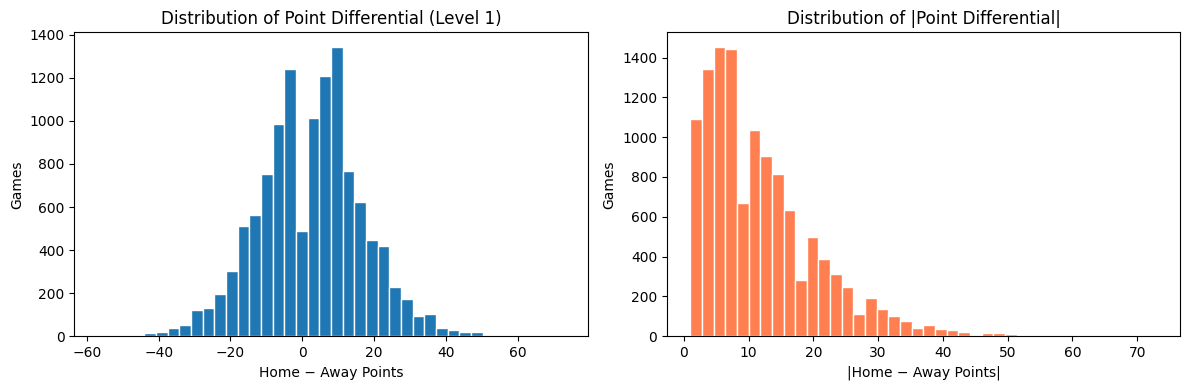


Games per season:
SEASON
2015-16    1230
2016-17    1230
2017-18    1230
2018-19    1230
2019-20    1059
2020-21    1080
2021-22    1230
2022-23    1230
2023-24    1230
2024-25    1225
Name: GAME_ID, dtype: int64


In [23]:
# ── Quick sanity check ─────────────────────────────────────────────────────────

print('Target statistics:')
print(df_level1_clean[TARGET_COL].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_level1_clean[TARGET_COL], bins=40, edgecolor='white')
axes[0].set_title('Distribution of Point Differential (Level 1)')
axes[0].set_xlabel('Home − Away Points')
axes[0].set_ylabel('Games')

axes[1].hist(df_level1_clean[TARGET_COL].abs(), bins=40, edgecolor='white', color='coral')
axes[1].set_title('Distribution of |Point Differential|')
axes[1].set_xlabel('|Home − Away Points|')
axes[1].set_ylabel('Games')

plt.tight_layout()
plt.savefig('results/level1_target_distribution.png', dpi=150)
plt.show()

# Games per season
print('\nGames per season:')
print(df_level1_clean.groupby('SEASON')['GAME_ID'].count())

### Feature Engineering — Level 1

**Added derived features:**
- `HOME_ADV = 1.0` — home court advantage indicator
- `DIFF_<stat>` = `HOME_<stat> − AWAY_<stat>` for every stat in `STAT_FEATURES`

Differential features directly encode relative team strength and are often the most predictive features for game outcomes.

In [24]:
# ── Level 1 feature engineering: home advantage + differential features ───────

# Add home court advantage indicator (not yet in L1)
df_level1_clean = df_level1_clean.copy()
df_level1_clean['HOME_ADV'] = 1.0

# Differential features: HOME_stat − AWAY_stat
diff_added_l1 = []
for stat in STAT_FEATURES:
    hcol, acol = f'HOME_{stat}', f'AWAY_{stat}'
    if hcol in df_level1_clean.columns and acol in df_level1_clean.columns:
        df_level1_clean[f'DIFF_{stat}'] = (
            df_level1_clean[hcol] - df_level1_clean[acol]
        )
        diff_added_l1.append(f'DIFF_{stat}')

L1_FEATURE_COLS = L1_FEATURE_COLS + ['HOME_ADV'] + diff_added_l1
print(f'L1 feature count after engineering: {len(L1_FEATURE_COLS)}')
print(f'  Original : {len(L1_FEATURE_COLS) - 1 - len(diff_added_l1)} team stats (HOME+AWAY)')
print(f'  +1 HOME_ADV, +{len(diff_added_l1)} DIFF features')

# Correlation with target (absolute value, sorted)
corr_l1 = (
    df_level1_clean[L1_FEATURE_COLS + ['POINT_DIFF']]
    .corr()['POINT_DIFF']
    .drop('POINT_DIFF')
    .abs()
    .sort_values(ascending=False)
)
print('\nTop 10 features by |correlation| with POINT_DIFF (Level 1):')
print(corr_l1.head(10).to_string())

# Quick stats
print('\nFeature matrix stats:')
print(df_level1_clean[L1_FEATURE_COLS].describe().loc[['mean','std','min','max']].T.head(8).to_string())


L1 feature count after engineering: 52
  Original : 34 team stats (HOME+AWAY)
  +1 HOME_ADV, +17 DIFF features

Top 10 features by |correlation| with POINT_DIFF (Level 1):
DIFF_NET_RATING    0.462883
DIFF_W_PCT         0.447172
DIFF_OFF_RATING    0.398422
DIFF_DEF_RATING    0.363869
HOME_NET_RATING    0.353258
DIFF_EFG_PCT       0.344903
HOME_W_PCT         0.342730
AWAY_NET_RATING    0.314313
AWAY_W_PCT         0.302127
DIFF_FG_PCT        0.302084

Feature matrix stats:
                  mean       std     min     max
HOME_GP      80.100050  4.194094  64.000  82.000
HOME_W_PCT    0.499893  0.146513   0.122   0.890
HOME_REB     44.047219  1.892588  38.600  51.700
HOME_AST     24.509537  2.393683  18.000  31.000
HOME_STL      7.673334  0.793672   5.700  10.300
HOME_BLK      4.861450  0.722633   2.400   7.500
HOME_TOV     14.079247  1.118103  11.100  17.200
HOME_FG_PCT   0.463479  0.016214   0.414   0.507


In [25]:
# ── Train / val / test split for Level 1 ──────────────────────────────────────

df_train_l1 = df_level1_clean[df_level1_clean['SEASON'].isin(TRAIN_SEASONS)]
df_val_l1   = df_level1_clean[df_level1_clean['SEASON'].isin(VAL_SEASONS)]
df_test_l1  = df_level1_clean[df_level1_clean['SEASON'].isin(TEST_SEASONS)]

X_train_l1 = df_train_l1[L1_FEATURE_COLS].values.astype(np.float32)
y_train_l1 = df_train_l1[TARGET_COL].values.astype(np.float32)

X_val_l1   = df_val_l1[L1_FEATURE_COLS].values.astype(np.float32)
y_val_l1   = df_val_l1[TARGET_COL].values.astype(np.float32)

X_test_l1  = df_test_l1[L1_FEATURE_COLS].values.astype(np.float32)
y_test_l1  = df_test_l1[TARGET_COL].values.astype(np.float32)

# Scale features (fit on train only)
scaler_l1 = StandardScaler()
X_train_l1 = scaler_l1.fit_transform(X_train_l1)
X_val_l1   = scaler_l1.transform(X_val_l1)
X_test_l1  = scaler_l1.transform(X_test_l1)

print(f'Train : {X_train_l1.shape}')
print(f'Val   : {X_val_l1.shape}')
print(f'Test  : {X_test_l1.shape}')

Train : (9519, 52)
Val   : (1230, 52)
Test  : (1225, 52)


---
## 3. Feature Engineering & Preprocessing

Feature engineering is applied to all four granularity levels before model training. For each level we:
1. Add **home advantage** indicator where missing.
2. Add **differential features** (`HOME_stat − AWAY_stat`) to encode relative team strength directly.
3. (Level 3 only) Add **team-aggregate** features (mean of top-8 player slots).
4. Compute **Pearson correlations** with the target to identify the most predictive features.
5. **Standardize** all features (`StandardScaler`, fit on train split only).

The level-specific feature engineering code is co-located with each level's data section below.

---
## 4. Model Definitions

Three model families are trained on **each** of the four granularity levels (12 runs total).
All hyperparameters are fixed across levels so differences in metric reflect data richness, not tuning.

### A. Ridge Regression (Baseline)
A regularised linear model.  `RidgeCV` searches over α ∈ {0.1, 1, 10, 100} via leave-one-out CV on the training set.

### B. XGBoost (Gradient-Boosted Trees)
| Hyperparameter | Value |
|---|---|
| `n_estimators` | 500 (early stopping on val RMSE, patience 20) |
| `max_depth` | 6 |
| `learning_rate` | 0.05 |
| `subsample` | 0.8 |
| `colsample_bytree` | 0.8 |

### C. Fully Connected Neural Network (PyTorch — `PointDiffNet`)
```
Input → Linear(256) → ReLU → BN → Dropout(0.3)
      → Linear(128) → ReLU → BN → Dropout(0.3)
      → Linear(64)  → ReLU
      → Linear(1)
```
Trained with Adam (lr = 1e-3, weight decay = 1e-4), MSE loss, batch size 64, up to 200 epochs.
Early stopping with patience = 15 on validation loss; best weights are restored.

In [26]:
import joblib

# ── A. Ridge factory ──────────────────────────────────────────────────────────
def make_ridge():
    return RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])


# ── B. XGBoost factory ────────────────────────────────────────────────────────
def make_xgb():
    return XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=20,
        eval_metric='rmse',
        random_state=SEED,
        verbosity=0,
    )


# ── C. PointDiffNet (PyTorch) ─────────────────────────────────────────────────
class PointDiffNet(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_nn(
    X_train, y_train,
    X_val,   y_val,
    input_dim: int,
    epochs: int     = 200,
    batch_size: int = 64,
    lr: float       = 1e-3,
    weight_decay: float = 1e-4,
    patience: int   = 15,
    device: str     = None,
):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model     = PointDiffNet(input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    t_X = torch.tensor(X_train, dtype=torch.float32)
    t_y = torch.tensor(y_train, dtype=torch.float32)
    v_X = torch.tensor(X_val,   dtype=torch.float32).to(device)
    v_y = torch.tensor(y_val,   dtype=torch.float32).to(device)
    loader = DataLoader(TensorDataset(t_X, t_y), batch_size=batch_size, shuffle=True)

    best_val, best_state, wait = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(t_X)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(v_X), v_y).item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'    Early stop at epoch {epoch + 1}  (best val MSE={best_val:.3f})')
                break

    model.load_state_dict(best_state)
    return model, history


def predict_nn(model, X, device=None):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy()


print('make_ridge / make_xgb / PointDiffNet / train_nn / predict_nn  — defined.')

make_ridge / make_xgb / PointDiffNet / train_nn / predict_nn  — defined.


---
## 5. Training Loop

`train_level()` encapsulates the full 3-model training run for one dataset.
It is called once per granularity level; per-level diagnostic cells follow each call.

**What it does for each model:**
1. Trains on the training split.
2. Records wall-clock training time.
3. Evaluates on the held-out test split (MSE, MAE, Median AE, R²).
4. Appends a result row to the shared `results` list.
5. Saves the model artefact to `models/`.

**Returns** a dict `{'ridge': (model, y_pred), 'xgb': (model, y_pred), 'nn': (model, history, y_pred)}`
so the calling cell can unpack named variables for the diagnostic plots below.

In [27]:
import time as time_module

results = []   # collects one dict per (granularity, model) pair


def evaluate(y_true, y_pred, granularity, model_name, train_time):
    """Return a metrics dict for one run."""
    return {
        'granularity': granularity,
        'model':       model_name,
        'mse':         mean_squared_error(y_true, y_pred),
        'mae':         mean_absolute_error(y_true, y_pred),
        'median_ae':   median_absolute_error(y_true, y_pred),
        'r2':          r2_score(y_true, y_pred),
        'train_time':  train_time,
    }


def train_level(granularity, X_tr, y_tr, X_v, y_v, X_te, y_te, tag):
    """
    Train Ridge, XGBoost, and PointDiffNet on one preprocessed dataset.

    Parameters
    ----------
    granularity : str   Human-readable label stored in `results`.
    X_tr / y_tr : train arrays (already scaled).
    X_v  / y_v  : validation arrays (XGB early-stop, NN patience).
    X_te / y_te : held-out test arrays.
    tag         : str   Short suffix for saved artefact filenames.

    Returns
    -------
    dict  {'ridge': (model, y_pred_test),
           'xgb':   (model, y_pred_test),
           'nn':    (model, history, y_pred_test)}
    """
    out = {}
    sep = '─' * 55

    # ── Ridge ─────────────────────────────────────────────────────────────────
    print(sep)
    print(f'[{granularity}]  A. Ridge Regression')
    t0 = time_module.time()
    ridge = make_ridge()
    ridge.fit(X_tr, y_tr)
    elapsed = time_module.time() - t0
    y_pred = ridge.predict(X_te)
    res    = evaluate(y_te, y_pred, granularity, 'Ridge', elapsed)
    results.append(res)
    print(f"    MSE={res['mse']:.2f}  MAE={res['mae']:.2f}  "
          f"R²={res['r2']:.3f}  α={ridge.alpha_}  ({elapsed:.1f}s)")
    joblib.dump(ridge, f'models/ridge_{tag}.pkl')
    out['ridge'] = (ridge, y_pred)

    # ── XGBoost ───────────────────────────────────────────────────────────────
    print(f'[{granularity}]  B. XGBoost')
    t0 = time_module.time()
    xgb_m = make_xgb()
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    elapsed = time_module.time() - t0
    y_pred  = xgb_m.predict(X_te)
    res     = evaluate(y_te, y_pred, granularity, 'XGBoost', elapsed)
    results.append(res)
    print(f"    MSE={res['mse']:.2f}  MAE={res['mae']:.2f}  "
          f"R²={res['r2']:.3f}  trees={xgb_m.best_iteration}  ({elapsed:.1f}s)")
    xgb_m.save_model(f'models/xgb_{tag}.json')
    out['xgb'] = (xgb_m, y_pred)

    # ── Neural Network ────────────────────────────────────────────────────────
    print(f'[{granularity}]  C. Neural Network')
    t0 = time_module.time()
    nn_m, hist = train_nn(X_tr, y_tr, X_v, y_v, input_dim=X_tr.shape[1])
    elapsed    = time_module.time() - t0
    y_pred     = predict_nn(nn_m, X_te)
    res        = evaluate(y_te, y_pred, granularity, 'NeuralNet', elapsed)
    results.append(res)
    print(f"    MSE={res['mse']:.2f}  MAE={res['mae']:.2f}  "
          f"R²={res['r2']:.3f}  ({elapsed:.1f}s)")
    torch.save(nn_m.state_dict(), f'models/nn_{tag}.pt')
    out['nn'] = (nn_m, hist, y_pred)

    return out


# ── Level 1 — Season Aggregates ───────────────────────────────────────────────
_r1 = train_level(
    'Level1_SeasonAgg',
    X_train_l1, y_train_l1,
    X_val_l1,   y_val_l1,
    X_test_l1,  y_test_l1,
    tag='level1',
)
ridge_l1,  y_pred_ridge_l1              = _r1['ridge']
xgb_l1,    y_pred_xgb_l1               = _r1['xgb']
nn_l1,     nn_l1_history, y_pred_nn_l1 = _r1['nn']

───────────────────────────────────────────────────────
[Level1_SeasonAgg]  A. Ridge Regression
    MSE=185.01  MAE=10.62  R²=0.261  α=100.0  (0.1s)
[Level1_SeasonAgg]  B. XGBoost
    MSE=190.00  MAE=10.76  R²=0.242  trees=82  (0.4s)
[Level1_SeasonAgg]  C. Neural Network
    Early stop at epoch 20  (best val MSE=187.634)
    MSE=188.55  MAE=10.73  R²=0.247  (3.7s)


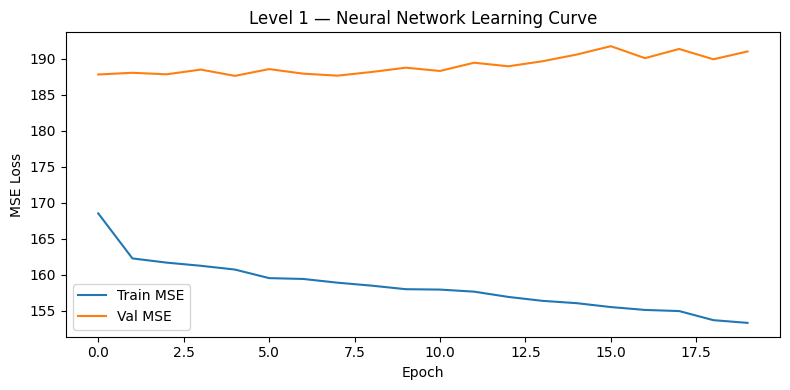

In [28]:
# ── Level 1 learning curves (Neural Network) ───────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(nn_l1_history['train_loss'], label='Train MSE')
ax.plot(nn_l1_history['val_loss'],   label='Val MSE')
ax.set_title('Level 1 — Neural Network Learning Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig('results/level1_nn_learning_curve.png', dpi=150)
plt.show()

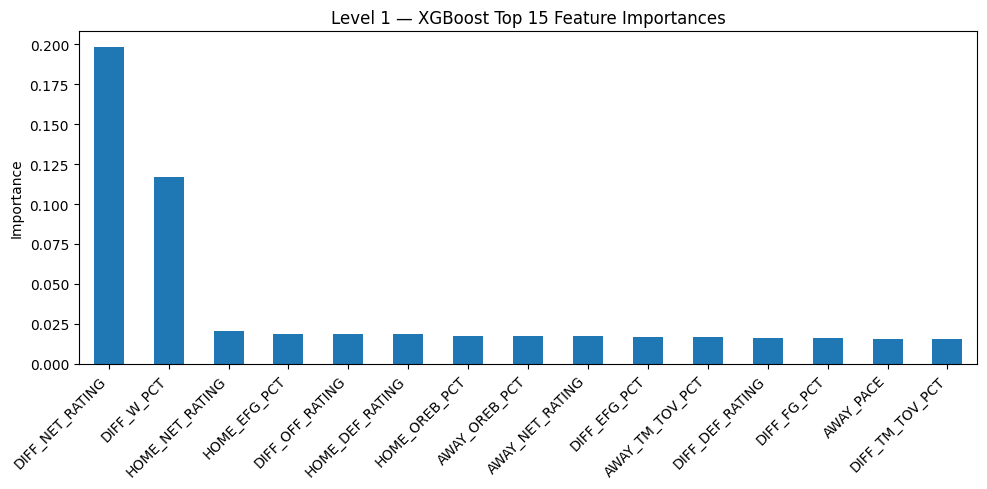

In [29]:
# ── Level 1 XGBoost feature importance ────────────────────────────────────────

importances = xgb_l1.feature_importances_
feat_imp = pd.Series(importances, index=L1_FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', ax=ax)
ax.set_title('Level 1 — XGBoost Top 15 Feature Importances')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/level1_xgb_feature_importance.png', dpi=150)
plt.show()

In [30]:
print(results)

[{'granularity': 'Level1_SeasonAgg', 'model': 'Ridge', 'mse': 185.01284790039062, 'mae': 10.624225616455078, 'median_ae': 8.54572868347168, 'r2': 0.2614701986312866, 'train_time': 0.11988449096679688}, {'granularity': 'Level1_SeasonAgg', 'model': 'XGBoost', 'mse': 190.00213623046875, 'mae': 10.763371467590332, 'median_ae': 8.503619194030762, 'r2': 0.24155408143997192, 'train_time': 0.3676004409790039}, {'granularity': 'Level1_SeasonAgg', 'model': 'NeuralNet', 'mse': 188.5465850830078, 'mae': 10.72981071472168, 'median_ae': 8.607261657714844, 'r2': 0.247364342212677, 'train_time': 3.667851448059082}]


Best Level 1 model: Ridge  MSE=185.01


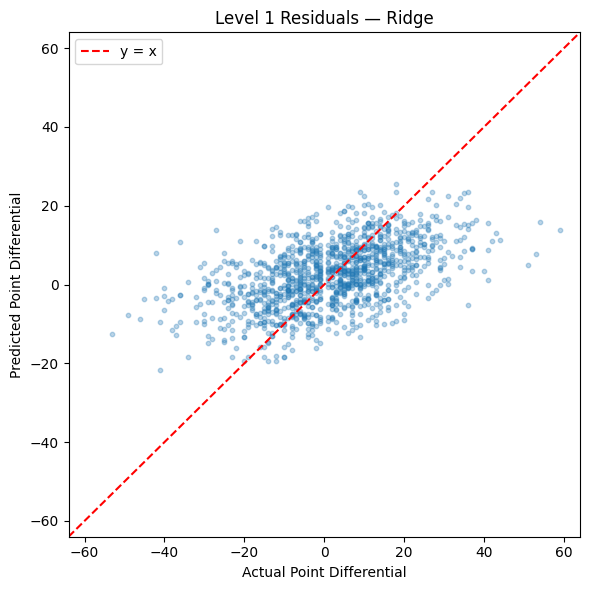

In [31]:
# ── Level 1 residual plot (best model) ────────────────────────────────────────

# Determine best model by test MSE so far
GRANULARITY = "Level1_SeasonAgg" # added
l1_results = [r for r in results if r['granularity'] == GRANULARITY]
best_l1    = min(l1_results, key=lambda r: r['mse'])
print(f"Best Level 1 model: {best_l1['model']}  MSE={best_l1['mse']:.2f}")

pred_map = {
    'Ridge':     y_pred_ridge_l1,
    'XGBoost':   y_pred_xgb_l1,
    'NeuralNet': y_pred_nn_l1,
}
best_pred = pred_map[best_l1['model']]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_l1, best_pred, alpha=0.3, s=10)
lim = max(abs(y_test_l1).max(), abs(best_pred).max()) + 5
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='y = x')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Actual Point Differential')
ax.set_ylabel('Predicted Point Differential')
ax.set_title(f'Level 1 Residuals — {best_l1["model"]}')
ax.legend()
plt.tight_layout()
plt.savefig('results/level1_residuals.png', dpi=150)
plt.show()

---
## Level 2 — Game-Level Team Stats with 10-Game Rolling Averages

We reuse the already-cached `LeagueGameFinder` data (one row per team per game) and compute a **rolling 10-game average** of each box-score stat *before* each game using `.shift(1)` to prevent leakage.

**Features per team (`HOME_*` / `AWAY_*`):** rolling mean over last 10 games of PTS, REB, AST, STL, BLK, TOV, FGM, FGA, FG\_PCT, FG3M, FG3A, FG3\_PCT, FTM, FTA, FT\_PCT, OREB, DREB, PLUS\_MINUS, plus ROLL\_WIN\_RATE (fraction of last 10 games won). A scalar `HOME_ADV = 1.0` indicator is appended.

**Target:** home − away point differential.

In [32]:
# ── Level 2: build rolling 10-game averages per team ─────────────────────────
#
# df_games was already pulled and cached during Level 1 data collection.
# LeagueGameFinder returns one row per team per game with full box-score stats.

ROLL_WINDOW = 10

# Box-score columns available in LeagueGameFinder results
L2_BOX_COLS = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV',
               'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
               'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'PLUS_MINUS']


def build_rolling_team_features(df_games_raw: pd.DataFrame,
                                box_cols: list,
                                window: int = 10) -> pd.DataFrame:
    """
    Given the raw LeagueGameFinder DataFrame (one row per team per game),
    return a DataFrame with per-team rolling averages of box_cols computed
    *before* each game (shift(1) prevents current-game leakage).
    Also computes ROLL_WIN_RATE = rolling win fraction.
    """
    df = df_games_raw.copy()
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
    df['IS_HOME']   = ~df['MATCHUP'].str.contains('@')

    # Binary win flag
    if 'WL' in df.columns:
        df['WIN'] = (df['WL'] == 'W').astype(float)
    else:
        df['WIN'] = (df['PLUS_MINUS'] > 0).astype(float)

    # Keep only the columns we need
    keep = (['GAME_ID', 'GAME_DATE', 'SEASON', 'TEAM_ID', 'IS_HOME', 'WIN'] +
            [c for c in box_cols if c in df.columns])
    df = df[keep].copy()

    # Sort chronologically per team
    df = df.sort_values(['TEAM_ID', 'GAME_DATE']).reset_index(drop=True)

    roll_cols = [c for c in box_cols if c in df.columns]

    # Rolling averages — shift(1) so the current game is NOT included
    rolled = (
        df.groupby('TEAM_ID')[roll_cols + ['WIN']]
          .apply(lambda g: g.shift(1).rolling(window, min_periods=1).mean())
          .reset_index(level=0, drop=True)
    )
    rolled.columns = [f'ROLL_{c}' for c in rolled.columns]

    df = pd.concat([df, rolled], axis=1)

    # Rename ROLL_WIN → ROLL_WIN_RATE for clarity
    if 'ROLL_WIN' in df.columns:
        df = df.rename(columns={'ROLL_WIN': 'ROLL_WIN_RATE'})

    return df


df_roll = build_rolling_team_features(df_games, L2_BOX_COLS, ROLL_WINDOW)

ROLL_FEATURE_NAMES = [c for c in df_roll.columns if c.startswith('ROLL_')]
print(f'Rolling feature count per team : {len(ROLL_FEATURE_NAMES)}')
print('Rolling features:', ROLL_FEATURE_NAMES)
print('df_roll shape   :', df_roll.shape)
df_roll.head(3)

Rolling feature count per team : 19
Rolling features: ['ROLL_PTS', 'ROLL_REB', 'ROLL_AST', 'ROLL_STL', 'ROLL_BLK', 'ROLL_TOV', 'ROLL_FGM', 'ROLL_FGA', 'ROLL_FG_PCT', 'ROLL_FG3M', 'ROLL_FG3A', 'ROLL_FG3_PCT', 'ROLL_FTM', 'ROLL_FTA', 'ROLL_FT_PCT', 'ROLL_OREB', 'ROLL_DREB', 'ROLL_PLUS_MINUS', 'ROLL_WIN_RATE']
df_roll shape   : (23958, 43)


,GAME_ID,GAME_DATE,SEASON,TEAM_ID,IS_HOME,WIN,PTS,REB,AST,STL,...,ROLL_FG3M,ROLL_FG3A,ROLL_FG3_PCT,ROLL_FTM,ROLL_FTA,ROLL_FT_PCT,ROLL_OREB,ROLL_DREB,ROLL_PLUS_MINUS,ROLL_WIN_RATE
0,21500001,2015-10-27,2015-16,1610612737,True,0.0,94,40,22,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21500019,2015-10-29,2015-16,1610612737,False,1.0,112,39,26,11,...,8.0,27.0,0.2960,12.0,15.0,0.800,7.0,33.0,-12.0,0.0
2,21500026,2015-10-30,2015-16,1610612737,True,1.0,97,45,23,9,...,9.0,25.5,0.3565,15.0,20.5,0.746,7.0,32.5,-0.5,0.5


In [33]:
# ── Pair home and away rolling features per game ──────────────────────────────

home_roll = df_roll[df_roll['IS_HOME']].copy()
away_roll = df_roll[~df_roll['IS_HOME']].copy()

# Prefix rolling columns with HOME_ / AWAY_
home_rename = {c: f'HOME_{c}' for c in ROLL_FEATURE_NAMES}
away_rename = {c: f'AWAY_{c}' for c in ROLL_FEATURE_NAMES}

home_roll = home_roll.rename(columns={**home_rename, 'TEAM_ID': 'HOME_TEAM_ID'})
away_roll = away_roll.rename(columns={**away_rename, 'TEAM_ID': 'AWAY_TEAM_ID'})

home_cols = ['GAME_ID', 'GAME_DATE', 'SEASON', 'HOME_TEAM_ID'] + list(home_rename.values())
away_cols = ['GAME_ID', 'SEASON', 'AWAY_TEAM_ID'] + list(away_rename.values())

df_l2 = home_roll[home_cols].merge(
    away_roll[away_cols],
    on=['GAME_ID', 'SEASON'],
    how='inner'
)

# Join target from df_paired (computed in Level 1)
df_l2 = df_l2.merge(
    df_paired[['GAME_ID', 'SEASON', 'POINT_DIFF']],
    on=['GAME_ID', 'SEASON'],
    how='inner'
)

# Home advantage scalar indicator
df_l2['HOME_ADV'] = 1.0

print('df_l2 shape:', df_l2.shape)
df_l2.head(3)

df_l2 shape: (11974, 45)


,GAME_ID,GAME_DATE,SEASON,HOME_TEAM_ID,HOME_ROLL_PTS,HOME_ROLL_REB,HOME_ROLL_AST,HOME_ROLL_STL,HOME_ROLL_BLK,HOME_ROLL_TOV,...,AWAY_ROLL_FG3_PCT,AWAY_ROLL_FTM,AWAY_ROLL_FTA,AWAY_ROLL_FT_PCT,AWAY_ROLL_OREB,AWAY_ROLL_DREB,AWAY_ROLL_PLUS_MINUS,AWAY_ROLL_WIN_RATE,POINT_DIFF,HOME_ADV
0,21500001,2015-10-27,2015-16,1610612737,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-12,1.0
1,21500026,2015-10-30,2015-16,1610612737,103.0,39.5,24.0,10.0,4.0,15.0,...,0.250,22.0,29.00,0.759,11.0,32.00,-10.00,0.0,3,1.0
2,21500062,2015-11-04,2015-16,1610612737,99.0,44.6,23.6,9.6,3.8,14.2,...,0.215,15.0,20.75,0.701,9.0,29.75,-15.25,0.0,14,1.0


In [34]:
# ── Finalize Level 2 dataset ───────────────────────────────────────────────────

L2_FEATURE_COLS = (
    [f'HOME_{c}' for c in ROLL_FEATURE_NAMES] +
    [f'AWAY_{c}' for c in ROLL_FEATURE_NAMES] +
    ['HOME_ADV']
)
L2_FEATURE_COLS = [c for c in L2_FEATURE_COLS if c in df_l2.columns]

# Drop games where ANY rolling feature is NaN
# (first game of a team's season has no prior window)
df_level2_clean = df_l2.dropna(subset=L2_FEATURE_COLS + ['POINT_DIFF']).copy()

print(f'Level 2 dataset : {df_level2_clean.shape[0]} games, {len(L2_FEATURE_COLS)} features')
print(f'Dropped         : {len(df_l2) - len(df_level2_clean)} games (cold-start)')
print('\nFeature list:')
for f in L2_FEATURE_COLS:
    print(' ', f)

df_level2_clean.to_csv('data/processed/level2_rolling10.csv', index=False)
print('\nSaved → data/processed/level2_rolling10.csv')

Level 2 dataset : 11957 games, 39 features
Dropped         : 17 games (cold-start)

Feature list:
  HOME_ROLL_PTS
  HOME_ROLL_REB
  HOME_ROLL_AST
  HOME_ROLL_STL
  HOME_ROLL_BLK
  HOME_ROLL_TOV
  HOME_ROLL_FGM
  HOME_ROLL_FGA
  HOME_ROLL_FG_PCT
  HOME_ROLL_FG3M
  HOME_ROLL_FG3A
  HOME_ROLL_FG3_PCT
  HOME_ROLL_FTM
  HOME_ROLL_FTA
  HOME_ROLL_FT_PCT
  HOME_ROLL_OREB
  HOME_ROLL_DREB
  HOME_ROLL_PLUS_MINUS
  HOME_ROLL_WIN_RATE
  AWAY_ROLL_PTS
  AWAY_ROLL_REB
  AWAY_ROLL_AST
  AWAY_ROLL_STL
  AWAY_ROLL_BLK
  AWAY_ROLL_TOV
  AWAY_ROLL_FGM
  AWAY_ROLL_FGA
  AWAY_ROLL_FG_PCT
  AWAY_ROLL_FG3M
  AWAY_ROLL_FG3A
  AWAY_ROLL_FG3_PCT
  AWAY_ROLL_FTM
  AWAY_ROLL_FTA
  AWAY_ROLL_FT_PCT
  AWAY_ROLL_OREB
  AWAY_ROLL_DREB
  AWAY_ROLL_PLUS_MINUS
  AWAY_ROLL_WIN_RATE
  HOME_ADV

Saved → data/processed/level2_rolling10.csv


In [35]:
# ── Sanity checks ──────────────────────────────────────────────────────────────

print('Target statistics (Level 2):')
print(df_level2_clean['POINT_DIFF'].describe())
print('\nGames per season:')
print(df_level2_clean.groupby('SEASON')['GAME_ID'].count())

# Check null rate in raw rolling features before dropping
roll_null_rate = df_l2[[f'HOME_{c}' for c in ROLL_FEATURE_NAMES]].isna().mean().mean()
print(f'\nNull rate in raw HOME rolling features (before dropna): {roll_null_rate:.3%}')

# Confirm leakage guard: the first game of each team-season should have been dropped
sample_team = df_level2_clean['HOME_TEAM_ID'].iloc[0]
sample_season = df_level2_clean['SEASON'].iloc[0]
n_before = df_l2[(df_l2['HOME_TEAM_ID'] == sample_team) &
                  (df_l2['SEASON'] == sample_season)].shape[0]
n_after  = df_level2_clean[(df_level2_clean['HOME_TEAM_ID'] == sample_team) &
                             (df_level2_clean['SEASON'] == sample_season)].shape[0]
print(f'\nSample team {sample_team} in {sample_season}: {n_before} → {n_after} games after drop (cold-start removed)')

Target statistics (Level 2):
count    11957.000000
mean         2.202225
std         14.511319
min        -57.000000
25%         -8.000000
50%          3.000000
75%         11.000000
max         73.000000
Name: POINT_DIFF, dtype: float64

Games per season:
SEASON
2015-16    1213
2016-17    1230
2017-18    1230
2018-19    1230
2019-20    1059
2020-21    1080
2021-22    1230
2022-23    1230
2023-24    1230
2024-25    1225
Name: GAME_ID, dtype: int64

Null rate in raw HOME rolling features (before dropna): 0.134%

Sample team 1610612737 in 2015-16: 41 → 40 games after drop (cold-start removed)


### Feature Engineering — Level 2

**Added derived features:**
- `DIFF_ROLL_<stat>` = `HOME_ROLL_<stat> − AWAY_ROLL_<stat>` for all 19 rolling stats

These differentials capture the relative 10-game form advantage and complement the individual team averages already present.

In [36]:
# ── Level 2 feature engineering: differential rolling features ────────────────

df_level2_clean = df_level2_clean.copy()

diff_added_l2 = []
for feat in ROLL_FEATURE_NAMES:
    hcol, acol = f'HOME_{feat}', f'AWAY_{feat}'
    if hcol in df_level2_clean.columns and acol in df_level2_clean.columns:
        df_level2_clean[f'DIFF_{feat}'] = (
            df_level2_clean[hcol] - df_level2_clean[acol]
        )
        diff_added_l2.append(f'DIFF_{feat}')

L2_FEATURE_COLS = L2_FEATURE_COLS + diff_added_l2
print(f'L2 feature count after engineering: {len(L2_FEATURE_COLS)}')
print(f'  Original: {len(L2_FEATURE_COLS) - len(diff_added_l2)} (HOME + AWAY + HOME_ADV)')
print(f'  +{len(diff_added_l2)} DIFF rolling features')

corr_l2 = (
    df_level2_clean[L2_FEATURE_COLS + ['POINT_DIFF']]
    .corr()['POINT_DIFF']
    .drop('POINT_DIFF')
    .abs()
    .sort_values(ascending=False)
)
print('\nTop 10 features by |correlation| with POINT_DIFF (Level 2):')
print(corr_l2.head(10).to_string())


L2 feature count after engineering: 58
  Original: 39 (HOME + AWAY + HOME_ADV)
  +19 DIFF rolling features

Top 10 features by |correlation| with POINT_DIFF (Level 2):
DIFF_ROLL_PLUS_MINUS    0.342506
DIFF_ROLL_WIN_RATE      0.308889
HOME_ROLL_PLUS_MINUS    0.261171
HOME_ROLL_WIN_RATE      0.241176
AWAY_ROLL_PLUS_MINUS    0.228683
DIFF_ROLL_PTS           0.216797
DIFF_ROLL_FG_PCT        0.203548
AWAY_ROLL_WIN_RATE      0.202362
DIFF_ROLL_FGM           0.174140
DIFF_ROLL_FG3M          0.152163


In [37]:
# ── Train / val / test split for Level 2 ──────────────────────────────────────

df_train_l2 = df_level2_clean[df_level2_clean['SEASON'].isin(TRAIN_SEASONS)]
df_val_l2   = df_level2_clean[df_level2_clean['SEASON'].isin(VAL_SEASONS)]
df_test_l2  = df_level2_clean[df_level2_clean['SEASON'].isin(TEST_SEASONS)]

X_train_l2 = df_train_l2[L2_FEATURE_COLS].values.astype(np.float32)
y_train_l2 = df_train_l2['POINT_DIFF'].values.astype(np.float32)

X_val_l2   = df_val_l2[L2_FEATURE_COLS].values.astype(np.float32)
y_val_l2   = df_val_l2['POINT_DIFF'].values.astype(np.float32)

X_test_l2  = df_test_l2[L2_FEATURE_COLS].values.astype(np.float32)
y_test_l2  = df_test_l2['POINT_DIFF'].values.astype(np.float32)

# Scale features — fit on train only
scaler_l2 = StandardScaler()
X_train_l2 = scaler_l2.fit_transform(X_train_l2)
X_val_l2   = scaler_l2.transform(X_val_l2)
X_test_l2  = scaler_l2.transform(X_test_l2)

print(f'Train : {X_train_l2.shape}')
print(f'Val   : {X_val_l2.shape}')
print(f'Test  : {X_test_l2.shape}')

Train : (9502, 58)
Val   : (1230, 58)
Test  : (1225, 58)


---
### Level 2 — 10-Game Rolling Averages

In [38]:
_r2 = train_level(
    'Level2_Rolling10',
    X_train_l2, y_train_l2,
    X_val_l2,   y_val_l2,
    X_test_l2,  y_test_l2,
    tag='level2',
)
ridge_l2,  y_pred_ridge_l2              = _r2['ridge']
xgb_l2,    y_pred_xgb_l2               = _r2['xgb']
nn_l2,     nn_l2_history, y_pred_nn_l2 = _r2['nn']

───────────────────────────────────────────────────────
[Level2_Rolling10]  A. Ridge Regression
    MSE=209.51  MAE=11.39  R²=0.164  α=100.0  (0.0s)
[Level2_Rolling10]  B. XGBoost
    MSE=214.83  MAE=11.53  R²=0.142  trees=49  (0.1s)
[Level2_Rolling10]  C. Neural Network
    Early stop at epoch 17  (best val MSE=210.579)
    MSE=213.41  MAE=11.52  R²=0.148  (2.8s)


In [39]:
print(results[-1])

{'granularity': 'Level2_Rolling10', 'model': 'NeuralNet', 'mse': 213.41351318359375, 'mae': 11.524853706359863, 'median_ae': 9.38093090057373, 'r2': 0.14810115098953247, 'train_time': 2.75604510307312}


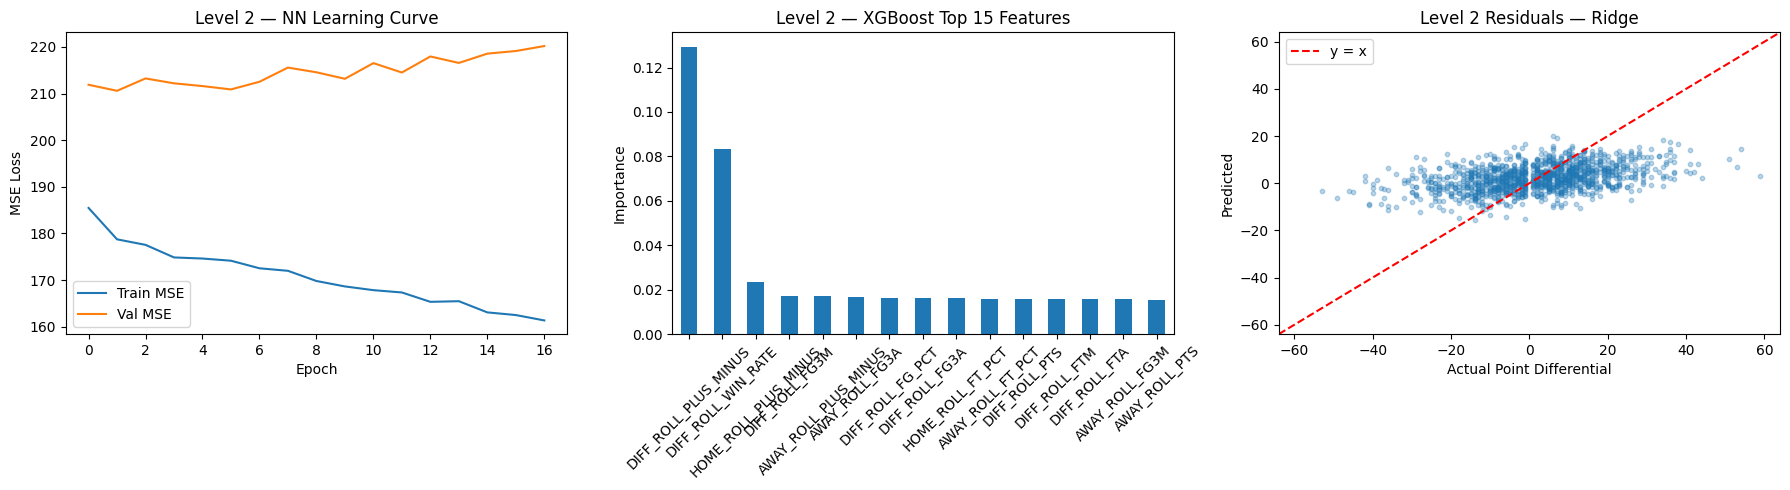

Best Level 2 model: Ridge  MSE=209.51  MAE=11.39  R²=0.164


In [40]:
# ── Level 2 diagnostic plots ───────────────────────────────────────────────────
GRANULARITY_L2 = "Level2_Rolling10" #added to make code work
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learning curve
axes[0].plot(nn_l2_history['train_loss'], label='Train MSE')
axes[0].plot(nn_l2_history['val_loss'],   label='Val MSE')
axes[0].set_title('Level 2 — NN Learning Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# XGBoost feature importance (top 15)
imp_l2 = pd.Series(xgb_l2.feature_importances_,
                   index=L2_FEATURE_COLS).sort_values(ascending=False)
imp_l2.head(15).plot(kind='bar', ax=axes[1])
axes[1].set_title('Level 2 — XGBoost Top 15 Features')
axes[1].set_ylabel('Importance')
axes[1].tick_params(axis='x', rotation=45)

# Residual scatter for best Level 2 model
l2_results   = [r for r in results if r['granularity'] == GRANULARITY_L2]
best_l2      = min(l2_results, key=lambda r: r['mse'])
pred_map_l2  = {'Ridge': y_pred_ridge_l2, 'XGBoost': y_pred_xgb_l2, 'NeuralNet': y_pred_nn_l2}
best_pred_l2 = pred_map_l2[best_l2['model']]

axes[2].scatter(y_test_l2, best_pred_l2, alpha=0.3, s=10)
lim = max(abs(y_test_l2).max(), abs(best_pred_l2).max()) + 5
axes[2].plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='y = x')
axes[2].set_xlim(-lim, lim)
axes[2].set_ylim(-lim, lim)
axes[2].set_xlabel('Actual Point Differential')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Level 2 Residuals — {best_l2["model"]}')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/level2_diagnostics.png', dpi=150)
plt.show()

print(f"Best Level 2 model: {best_l2['model']}  "
      f"MSE={best_l2['mse']:.2f}  MAE={best_l2['mae']:.2f}  R²={best_l2['r2']:.3f}")

---
## Level 3 — Player-Level Box Scores (Top 8 by Minutes, 5-Game Rolling Averages)

For each game we identify the **top 8 players by minutes played** on each team (16 players total), then use a **rolling 5-game average** of each player's box-score stats *before* the game as features. The 16 per-player vectors are sorted by descending minutes and flattened into a single row.

**Data source:** `LeagueGameLog` endpoint (one call per season, all players), cached to `data/raw/`.

**Features per player (10):** PTS, REB, AST, STL, BLK, TOV, MIN, FG\_PCT, FG3\_PCT, FT\_PCT — rolling mean over last 5 games (`shift(1).rolling(5, min_periods=1)`).

**Total features:** 8 players × 2 teams × 10 stats = **160**. Missing players (injury, DNP) are zero-padded.

**Target:** home − away point differential.

In [41]:
# ── Level 3: fetch all-player game logs per season ────────────────────────────
#
# LeagueGameLog with player_or_team_abbreviation='P' returns one row per
# player per game for the entire season — far more efficient than pulling
# each player individually via PlayerGameLog.

from nba_api.stats.endpoints import LeagueGameLog

L3_PLAYER_BOX_COLS = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV',
                      'MIN', 'FG_PCT', 'FG3_PCT', 'FT_PCT']
L3_ROLL_WINDOW = 5
TOP_N_PLAYERS  = 8   # top players per team by minutes


def fetch_player_game_log_season(season: str) -> pd.DataFrame:
    """Pull all player game logs for one season (one API call)."""
    time.sleep(1)
    endpoint = LeagueGameLog(
        season=season,
        season_type_all_star='Regular Season',
        player_or_team_abbreviation='P',
    )
    df = endpoint.get_data_frames()[0]
    df['SEASON'] = season
    return df


all_player_logs = []
for season in tqdm(ALL_SEASONS, desc='Pulling player game logs (L3)'):
    df_pl = load_or_fetch(
        f'player_gamelogs_{season}.csv',
        fetch_player_game_log_season,
        season=season,
    )
    all_player_logs.append(df_pl)

df_player_logs = pd.concat(all_player_logs, ignore_index=True)

print(f'Player game logs shape: {df_player_logs.shape}')
print('Columns:', df_player_logs.columns.tolist())
df_player_logs.head(3)

Pulling player game logs (L3):   0%|          | 0/10 [00:00<?, ?it/s]

Player game logs shape: (254513, 33)
Columns: ['SEASON_ID', 'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'FANTASY_PTS', 'VIDEO_AVAILABLE', 'SEASON']


,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,...,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,FANTASY_PTS,VIDEO_AVAILABLE,SEASON
0,22015,200757,Thabo Sefolosha,1610612737,ATL,Atlanta Hawks,21500001,2015-10-27,ATL vs. DET,L,...,3,4,0,0,1,2,-1,26.9,1,2015-16
1,22015,201952,Jeff Teague,1610612737,ATL,Atlanta Hawks,21500001,2015-10-27,ATL vs. DET,L,...,4,0,0,5,1,18,-23,21.4,1,2015-16
2,22015,203145,Kent Bazemore,1610612737,ATL,Atlanta Hawks,21500001,2015-10-27,ATL vs. DET,L,...,1,0,0,4,3,0,-17,5.9,1,2015-16


In [42]:
# ── Level 3: clean and compute per-player rolling 5-game averages ─────────────

df_pl = df_player_logs.copy()
df_pl['GAME_DATE'] = pd.to_datetime(df_pl['GAME_DATE'])

# Convert MIN from 'MM:SS' string to float minutes if needed
if df_pl['MIN'].dtype == object:
    def parse_min(m):
        try:
            parts = str(m).split(':')
            return float(parts[0]) + float(parts[1]) / 60 if len(parts) == 2 else float(parts[0])
        except Exception:
            return np.nan
    df_pl['MIN'] = df_pl['MIN'].apply(parse_min)
else:
    df_pl['MIN'] = pd.to_numeric(df_pl['MIN'], errors='coerce')

# Cast box-score columns to float
for col in L3_PLAYER_BOX_COLS:
    if col in df_pl.columns:
        df_pl[col] = pd.to_numeric(df_pl[col], errors='coerce')

# Identify the player & team ID columns (name may vary by API version)
player_id_col = 'PLAYER_ID' if 'PLAYER_ID' in df_pl.columns else None
team_id_col   = 'TEAM_ID'   if 'TEAM_ID'   in df_pl.columns else None
game_id_col   = 'GAME_ID'   if 'GAME_ID'   in df_pl.columns else None
assert player_id_col and team_id_col and game_id_col, \
    f"Missing expected columns. Available: {df_pl.columns.tolist()}"

# Sort chronologically per player
df_pl = df_pl.sort_values([player_id_col, 'GAME_DATE']).reset_index(drop=True)

# Available stat columns (intersect with what came back from the API)
stat_cols_avail = [c for c in L3_PLAYER_BOX_COLS if c in df_pl.columns]
print(f'Available stat cols: {stat_cols_avail}')

# Compute rolling 5-game averages per player — shift(1) to exclude current game
rolled_pl = (
    df_pl.groupby(player_id_col)[stat_cols_avail]
         .apply(lambda g: g.shift(1).rolling(L3_ROLL_WINDOW, min_periods=1).mean())
         .reset_index(level=0, drop=True)
)
rolled_pl.columns = [f'ROLL_{c}' for c in rolled_pl.columns]

df_pl = pd.concat([df_pl, rolled_pl], axis=1)

L3_PLAYER_ROLL_COLS = [f'ROLL_{c}' for c in stat_cols_avail]
print(f'Player rolling cols: {L3_PLAYER_ROLL_COLS}')
print(f'df_pl shape after rolling: {df_pl.shape}')
df_pl.head(3)

Available stat cols: ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'MIN', 'FG_PCT', 'FG3_PCT', 'FT_PCT']
Player rolling cols: ['ROLL_PTS', 'ROLL_REB', 'ROLL_AST', 'ROLL_STL', 'ROLL_BLK', 'ROLL_TOV', 'ROLL_MIN', 'ROLL_FG_PCT', 'ROLL_FG3_PCT', 'ROLL_FT_PCT']
df_pl shape after rolling: (254513, 43)


,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,...,ROLL_PTS,ROLL_REB,ROLL_AST,ROLL_STL,ROLL_BLK,ROLL_TOV,ROLL_MIN,ROLL_FG_PCT,ROLL_FG3_PCT,ROLL_FT_PCT
0,22015,708,Kevin Garnett,1610612750,MIN,Minnesota Timberwolves,21500017,2015-10-28,MIN @ LAL,W,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22015,708,Kevin Garnett,1610612750,MIN,Minnesota Timberwolves,21500029,2015-10-30,MIN @ DEN,W,...,4.0,7.0,2.0,0.0,1.0,0.0,13.0,0.5000,NaN,NaN
2,22015,708,Kevin Garnett,1610612750,MIN,Minnesota Timberwolves,21500050,2015-11-02,MIN vs. POR,L,...,4.0,6.5,1.0,1.0,0.5,0.0,17.5,0.4165,NaN,1.0


In [43]:
# ── Level 3: build per-game feature matrix ────────────────────────────────────
#
# For each game:
#   1. Collect all players who actually played (MIN > 0).
#   2. Per team, rank by actual minutes played in THIS game (descending).
#   3. Select top TOP_N_PLAYERS (8) by rank.
#   4. Use their *rolling* stats (pre-game) as features.
#   5. Sort players by rank and flatten: [home_p1_stats, ..., home_p8_stats,
#                                          away_p1_stats, ..., away_p8_stats]
#   6. Zero-pad if a team has fewer than 8 players with valid minutes.
#
# This builds a numpy array row per game.

N_FEATS_PER_PLAYER = len(L3_PLAYER_ROLL_COLS)
N_FEATS_PER_GAME   = TOP_N_PLAYERS * 2 * N_FEATS_PER_PLAYER  # 8 * 2 * 10 = 160

# Build a lookup: (GAME_ID, PLAYER_ID) → rolling stats array
# Keep only the rolling columns + keys to avoid memory bloat
df_pl_lookup = df_pl[[game_id_col, player_id_col, team_id_col, 'SEASON', 'MIN']
                     + L3_PLAYER_ROLL_COLS].copy()

# Use df_paired for the list of games (ensures we have POINT_DIFF)
game_ids  = df_paired['GAME_ID'].values
home_ids  = df_paired['HOME_TEAM_ID'].values
away_ids  = df_paired['AWAY_TEAM_ID'].values
targets   = df_paired['POINT_DIFF'].values
seasons   = df_paired['SEASON'].values
dates     = df_paired['GAME_DATE'].values

# Index the player log by GAME_ID for fast lookup
df_pl_lookup = df_pl_lookup.set_index(game_id_col)

def get_top8_rolling(game_id, team_id):
    """Return (8 × N_FEATS) array of rolling stats for top-8 players by MIN."""
    zero_row = np.zeros(N_FEATS_PER_PLAYER, dtype=np.float32)
    try:
        rows = df_pl_lookup.loc[[game_id]]  # all players in this game
    except KeyError:
        return np.zeros((TOP_N_PLAYERS, N_FEATS_PER_PLAYER), dtype=np.float32)

    team_rows = rows[rows[team_id_col] == team_id].copy()
    team_rows = team_rows.dropna(subset=['MIN'])
    team_rows = team_rows.sort_values('MIN', ascending=False).head(TOP_N_PLAYERS)

    out = np.zeros((TOP_N_PLAYERS, N_FEATS_PER_PLAYER), dtype=np.float32)
    for i, (_, row) in enumerate(team_rows.iterrows()):
        vals = row[L3_PLAYER_ROLL_COLS].values.astype(np.float32)
        # Replace NaN rolling values (cold-start) with 0
        vals = np.nan_to_num(vals, nan=0.0)
        out[i] = vals
    return out


print(f'Building Level 3 feature matrix for {len(game_ids)} games...')
print(f'Feature vector size: {N_FEATS_PER_GAME} ({TOP_N_PLAYERS} players × 2 teams × {N_FEATS_PER_PLAYER} stats)')

X_l3_rows = []
y_l3_rows = []
meta_rows = []   # (GAME_ID, SEASON, GAME_DATE)

for i in tqdm(range(len(game_ids)), desc='Building L3 features'):
    gid    = game_ids[i]
    home   = home_ids[i]
    away   = away_ids[i]
    target = targets[i]
    season = seasons[i]
    date   = dates[i]

    home_feats = get_top8_rolling(gid, home).flatten()  # 80
    away_feats = get_top8_rolling(gid, away).flatten()  # 80
    row = np.concatenate([home_feats, away_feats])       # 160

    X_l3_rows.append(row)
    y_l3_rows.append(target)
    meta_rows.append({'GAME_ID': gid, 'SEASON': season, 'GAME_DATE': date})

X_l3 = np.array(X_l3_rows, dtype=np.float32)
y_l3 = np.array(y_l3_rows, dtype=np.float32)
df_l3_meta = pd.DataFrame(meta_rows)

print(f'X_l3 shape: {X_l3.shape}')
print(f'y_l3 shape: {y_l3.shape}')

Building Level 3 feature matrix for 11974 games...
Feature vector size: 160 (8 players × 2 teams × 10 stats)


Building L3 features:   0%|          | 0/11974 [00:00<?, ?it/s]

X_l3 shape: (11974, 160)
y_l3 shape: (11974,)


In [ ]:
# ── Level 3: build column names + save processed dataset ──────────────────────

# Column names follow: HOME_P{1..8}_{stat}, AWAY_P{1..8}_{stat}
L3_FEATURE_COLS = []
for side in ['HOME', 'AWAY']:
    for p in range(1, TOP_N_PLAYERS + 1):
        for stat in L3_PLAYER_ROLL_COLS:
            L3_FEATURE_COLS.append(f'{side}_P{p}_{stat}')

assert len(L3_FEATURE_COLS) == N_FEATS_PER_GAME, \
    f"Column count mismatch: {len(L3_FEATURE_COLS)} vs {N_FEATS_PER_GAME}"

df_level3 = pd.DataFrame(X_l3, columns=L3_FEATURE_COLS, dtype=np.float32)
df_level3['GAME_ID']    = df_l3_meta['GAME_ID'].values
df_level3['SEASON']     = df_l3_meta['SEASON'].values
df_level3['GAME_DATE']  = df_l3_meta['GAME_DATE'].values
df_level3['POINT_DIFF'] = y_l3

# Drop rows where ALL home or ALL away player features are zero
# (game_id not found in player logs — very rare, e.g. preseason games)
home_feat_cols = [c for c in L3_FEATURE_COLS if c.startswith('HOME_P1_')]
away_feat_cols = [c for c in L3_FEATURE_COLS if c.startswith('AWAY_P1_')]
df_level3_clean = df_level3[
    (df_level3[home_feat_cols].abs().sum(axis=1) > 0) &
    (df_level3[away_feat_cols].abs().sum(axis=1) > 0)
].copy()

print(f'Level 3 dataset : {df_level3_clean.shape[0]} games, {len(L3_FEATURE_COLS)} features')
print(f'Dropped         : {len(df_level3) - len(df_level3_clean)} games (no player log match)')
print(f'\nSample feature names: {L3_FEATURE_COLS[:6]} ...')

df_level3_clean.to_csv('data/processed/level3_player_rolling5.csv', index=False)
print('\nSaved → data/processed/level3_player_rolling5.csv')

Level 3 dataset : 11945 games, 160 features
Dropped         : 29 games (no player log match)

Sample feature names: ['HOME_P1_ROLL_PTS', 'HOME_P1_ROLL_REB', 'HOME_P1_ROLL_AST', 'HOME_P1_ROLL_STL', 'HOME_P1_ROLL_BLK', 'HOME_P1_ROLL_TOV'] ...

Saved → data/processed/level3_player_rolling5.csv


In [45]:
# ── Sanity checks ──────────────────────────────────────────────────────────────

print('Target statistics (Level 3):')
print(df_level3_clean['POINT_DIFF'].describe())
print('\nGames per season:')
print(df_level3_clean.groupby('SEASON')['GAME_ID'].count())

# Check zero-padding rate — fraction of player slots that are all-zero (DNP / injury)
zero_pct = (X_l3 == 0).all(axis=1).mean()
n_zero_feats = (X_l3 == 0).mean()  # per-feature zero rate
print(f'\nFraction of games where entire feature vector is zero: {zero_pct:.3%}')
print(f'Mean zero rate across all 160 features: {n_zero_feats.mean():.3%}')

# Quick spot check: star player should have non-zero rolling stats
print('\nSample row (first 20 features):', df_level3_clean[L3_FEATURE_COLS[:20]].iloc[0].values)

Target statistics (Level 3):
count    11945.000000
mean         2.204018
std         14.506650
min        -57.000000
25%         -8.000000
50%          3.000000
75%         11.000000
max         73.000000
Name: POINT_DIFF, dtype: float64

Games per season:
SEASON
2015-16    1213
2016-17    1228
2017-18    1228
2018-19    1229
2019-20    1058
2020-21    1079
2021-22    1228
2022-23    1228
2023-24    1229
2024-25    1225
Name: GAME_ID, dtype: int64

Fraction of games where entire feature vector is zero: 0.109%
Mean zero rate across all 160 features: 5.564%

Sample row (first 20 features): [15.      9.5     4.      2.5     0.      2.5    35.5     0.37    0.4165
  0.625  18.      6.5     2.5     2.      3.      2.     30.5     0.5225
  0.3665  0.5835]


### Feature Engineering — Level 3

**Added derived features:**
- `HOME_TEAM_ROLL_<stat>` / `AWAY_TEAM_ROLL_<stat>` — mean of top-8 players' rolling stat per team (20 aggregate features)
- `DIFF_TEAM_ROLL_<stat>` — HOME team aggregate minus AWAY team aggregate (10 differential features)

This gives models a compact team-level signal alongside the 160-slot player features.

In [46]:
# ── Level 3 feature engineering: team-level player aggregates + differentials ─
#
# 160 individual player slots are hard for linear models to interpret.
# We add 20 compact team-aggregate features (mean of top-8 players' rolling stats
# per team × 2 sides) plus 10 differential features.
# The full 160-feature set is kept — this augments it.

df_level3_clean = df_level3_clean.copy()

# Mean of top-8 players' rolling stats per side
for side in ['HOME', 'AWAY']:
    for stat in L3_PLAYER_ROLL_COLS:
        slot_cols = [f'{side}_P{p}_{stat}' for p in range(1, TOP_N_PLAYERS + 1)
                     if f'{side}_P{p}_{stat}' in df_level3_clean.columns]
        if slot_cols:
            df_level3_clean[f'{side}_TEAM_{stat}'] = df_level3_clean[slot_cols].mean(axis=1)

team_agg_home = [c for c in df_level3_clean.columns if c.startswith('HOME_TEAM_')]
team_agg_away = [c for c in df_level3_clean.columns if c.startswith('AWAY_TEAM_')]

# Differential of team aggregates
diff_added_l3 = []
for stat in L3_PLAYER_ROLL_COLS:
    hcol, acol = f'HOME_TEAM_{stat}', f'AWAY_TEAM_{stat}'
    if hcol in df_level3_clean.columns and acol in df_level3_clean.columns:
        df_level3_clean[f'DIFF_TEAM_{stat}'] = (
            df_level3_clean[hcol] - df_level3_clean[acol]
        )
        diff_added_l3.append(f'DIFF_TEAM_{stat}')

L3_FEATURE_COLS = L3_FEATURE_COLS + team_agg_home + team_agg_away + diff_added_l3
print(f'L3 feature count after engineering: {len(L3_FEATURE_COLS)}')
print(f'  Original player slots   : {TOP_N_PLAYERS * 2 * len(L3_PLAYER_ROLL_COLS)}')
print(f'  +{len(team_agg_home)} HOME team agg, +{len(team_agg_away)} AWAY team agg, +{len(diff_added_l3)} DIFF team agg')

corr_l3 = (
    df_level3_clean[L3_FEATURE_COLS + ['POINT_DIFF']]
    .corr()['POINT_DIFF']
    .drop('POINT_DIFF')
    .abs()
    .sort_values(ascending=False)
)
print('\nTop 10 features by |correlation| with POINT_DIFF (Level 3):')
print(corr_l3.head(10).to_string())


L3 feature count after engineering: 190
  Original player slots   : 160
  +10 HOME team agg, +10 AWAY team agg, +10 DIFF team agg



Top 10 features by |correlation| with POINT_DIFF (Level 3):
DIFF_TEAM_ROLL_PTS       0.207338
DIFF_TEAM_ROLL_AST       0.173379
DIFF_TEAM_ROLL_REB       0.155451
DIFF_TEAM_ROLL_FG_PCT    0.153819
AWAY_TEAM_ROLL_PTS       0.143718
DIFF_TEAM_ROLL_MIN       0.129505
AWAY_TEAM_ROLL_AST       0.129166
HOME_TEAM_ROLL_PTS       0.126407
DIFF_TEAM_ROLL_BLK       0.123452
DIFF_TEAM_ROLL_STL       0.120073


In [47]:
# ── Train / val / test split for Level 3 ──────────────────────────────────────

train_mask_l3 = df_level3_clean['SEASON'].isin(TRAIN_SEASONS)
val_mask_l3   = df_level3_clean['SEASON'].isin(VAL_SEASONS)
test_mask_l3  = df_level3_clean['SEASON'].isin(TEST_SEASONS)

X_train_l3 = df_level3_clean.loc[train_mask_l3, L3_FEATURE_COLS].values.astype(np.float32)
y_train_l3 = df_level3_clean.loc[train_mask_l3, 'POINT_DIFF'].values.astype(np.float32)

X_val_l3   = df_level3_clean.loc[val_mask_l3,   L3_FEATURE_COLS].values.astype(np.float32)
y_val_l3   = df_level3_clean.loc[val_mask_l3,   'POINT_DIFF'].values.astype(np.float32)

X_test_l3  = df_level3_clean.loc[test_mask_l3,  L3_FEATURE_COLS].values.astype(np.float32)
y_test_l3  = df_level3_clean.loc[test_mask_l3,  'POINT_DIFF'].values.astype(np.float32)

# Scale features — fit on train only
scaler_l3 = StandardScaler()
X_train_l3 = scaler_l3.fit_transform(X_train_l3)
X_val_l3   = scaler_l3.transform(X_val_l3)
X_test_l3  = scaler_l3.transform(X_test_l3)

print(f'Train : {X_train_l3.shape}')
print(f'Val   : {X_val_l3.shape}')
print(f'Test  : {X_test_l3.shape}')

Train : (9491, 190)
Val   : (1229, 190)
Test  : (1225, 190)


---
### Level 3 — Player-Level Rolling Averages

In [48]:
_r3 = train_level(
    'Level3_PlayerRolling5',
    X_train_l3, y_train_l3,
    X_val_l3,   y_val_l3,
    X_test_l3,  y_test_l3,
    tag='level3',
)
ridge_l3,  y_pred_ridge_l3              = _r3['ridge']
xgb_l3,    y_pred_xgb_l3               = _r3['xgb']
nn_l3,     nn_l3_history, y_pred_nn_l3 = _r3['nn']

───────────────────────────────────────────────────────
[Level3_PlayerRolling5]  A. Ridge Regression
    MSE=228.58  MAE=11.72  R²=0.088  α=100.0  (0.6s)
[Level3_PlayerRolling5]  B. XGBoost
    MSE=228.01  MAE=11.76  R²=0.090  trees=124  (0.4s)
[Level3_PlayerRolling5]  C. Neural Network
    Early stop at epoch 17  (best val MSE=218.183)
    MSE=229.02  MAE=11.77  R²=0.086  (2.8s)


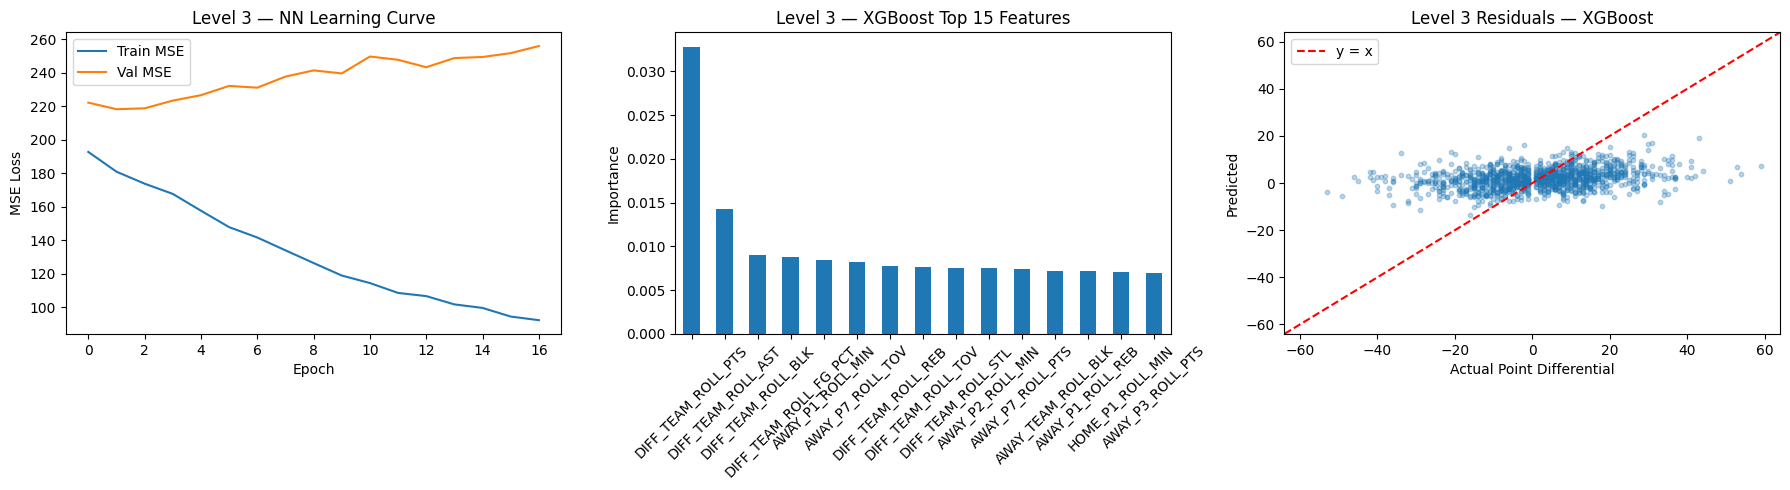

Best Level 3 model: XGBoost  MSE=228.01  MAE=11.76  R²=0.090


In [49]:
# ── Level 3 diagnostic plots ───────────────────────────────────────────────────
GRANULARITY_L3 = "Level3_PlayerRolling5"
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learning curve
axes[0].plot(nn_l3_history['train_loss'], label='Train MSE')
axes[0].plot(nn_l3_history['val_loss'],   label='Val MSE')
axes[0].set_title('Level 3 — NN Learning Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# XGBoost feature importance (top 15)
imp_l3 = pd.Series(xgb_l3.feature_importances_,
                   index=L3_FEATURE_COLS).sort_values(ascending=False)
imp_l3.head(15).plot(kind='bar', ax=axes[1])
axes[1].set_title('Level 3 — XGBoost Top 15 Features')
axes[1].set_ylabel('Importance')
axes[1].tick_params(axis='x', rotation=45)

# Residual scatter for best Level 3 model
l3_results   = [r for r in results if r['granularity'] == GRANULARITY_L3]
best_l3      = min(l3_results, key=lambda r: r['mse'])
pred_map_l3  = {'Ridge': y_pred_ridge_l3, 'XGBoost': y_pred_xgb_l3, 'NeuralNet': y_pred_nn_l3}
best_pred_l3 = pred_map_l3[best_l3['model']]

axes[2].scatter(y_test_l3, best_pred_l3, alpha=0.3, s=10)
lim = max(abs(y_test_l3).max(), abs(best_pred_l3).max()) + 5
axes[2].plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='y = x')
axes[2].set_xlim(-lim, lim)
axes[2].set_ylim(-lim, lim)
axes[2].set_xlabel('Actual Point Differential')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Level 3 Residuals — {best_l3["model"]}')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/level3_diagnostics.png', dpi=150)
plt.show()

print(f"Best Level 3 model: {best_l3['model']}  "
      f"MSE={best_l3['mse']:.2f}  MAE={best_l3['mae']:.2f}  R²={best_l3['r2']:.3f}")

---
## Level 4 — Possession-Level Play-by-Play Aggregates (5-Game Rolling Averages)

For each game we parse the `PlayByPlayV2` event log and compute **per-team possession-level features**, then roll those over the team's last 5 games before tip-off.

**Data source:** `PlayByPlayV2` (one call per game, cached). ~12,000 calls total; all responses cached to `data/raw/pbp_{GAME_ID}.csv`. Expect ~3–5 hours of pull time on first run; subsequent runs load from cache instantly.

**Features computed per team per game (8):**
| Feature | Definition |
|---|---|
| `PTS_PER_POSS` | Points scored ÷ possessions |
| `TOV_RATE` | Turnovers ÷ possessions |
| `OREB_RATE` | Offensive rebounds ÷ (opp defensive rebound opportunities) |
| `FT_RATE` | Free throw attempts ÷ field goal attempts |
| `3PA_RATE` | 3-point attempts ÷ field goal attempts |
| `FAST_BREAK_RATE` | Fast-break scoring plays ÷ possessions |
| `PAINT_TOUCH_RATE` | Paint-touch scoring plays ÷ possessions |
| `2ND_CHANCE_RATE` | Second-chance points plays ÷ possessions |

Rolling 5-game averages (`shift(1).rolling(5, min_periods=1)`) prevent leakage. **Total features: 8 × 2 teams = 16.**

In [50]:
# ── Level 4: play-by-play parsing helpers ─────────────────────────────────────
#
# PlayByPlayV2 event codes used here:
#   EVENTMSGTYPE  1 = made FG, 2 = missed FG, 3 = free throw,
#                 4 = rebound, 5 = turnover, 6 = foul,
#                 12 = start of period, 13 = end of period
#
# HOMEDESCRIPTION / VISITORDESCRIPTION contain text we can match for
# fast-break ("Fast Break"), paint ("Paint"), 2nd-chance ("2nd Chance").
# EVENTMSGACTIONTYPE 1 = jump shot, can be used to detect 3PA vs 2PA with
# SCORE / scorediff, but simpler: check if description contains "3PT".

L4_ROLL_WINDOW = 5

PBP_TEAM_FEATURES = [
    'PTS_PER_POSS', 'TOV_RATE', 'OREB_RATE', 'FT_RATE',
    '3PA_RATE', 'FAST_BREAK_RATE', 'PAINT_TOUCH_RATE', '2ND_CHANCE_RATE',
]


def fetch_pbp(game_id: str) -> pd.DataFrame:
    """Fetch play-by-play for a single game."""
    time.sleep(0.6)  # slightly faster than 1s — PBP is lighter
    endpoint = PlayByPlayV2(game_id=game_id)
    df = endpoint.get_data_frames()[0]
    return df


def load_or_fetch_pbp(game_id: str) -> pd.DataFrame:
    """Load PBP from cache or pull from API."""
    path = cache_path(f'pbp_{game_id}.csv')
    if os.path.exists(path):
        return pd.read_csv(path)
    df = fetch_pbp(game_id)
    df.to_csv(path, index=False)
    return df


def parse_possessions(df_pbp: pd.DataFrame, home_team_id: int, away_team_id: int) -> dict:
    """
    Parse a single game's PBP DataFrame and return a dict of
    per-team possession-level features.

    A possession ends on: made FG, turnover, or defensive rebound after a miss.
    We use a simple approximation: possession count ≈ FGA + TOV + 0.44*FTA - OREB.
    (Dean Oliver formula, standard in sports analytics.)
    """
    feats = {}

    for team_id, side in [(home_team_id, 'HOME'), (away_team_id, 'AWAY')]:
        # Determine which description column belongs to this team
        # In PBP data: home team events appear in HOMEDESCRIPTION,
        # away team events in VISITORDESCRIPTION
        if side == 'HOME':
            desc_col  = 'HOMEDESCRIPTION'
            o_desc_col = 'VISITORDESCRIPTION'
        else:
            desc_col  = 'VISITORDESCRIPTION'
            o_desc_col = 'HOMEDESCRIPTION'

        # Safe helper — return empty string if col missing
        def desc(row):
            v = row.get(desc_col, '') or ''
            return str(v).upper()

        def o_desc(row):
            v = row.get(o_desc_col, '') or ''
            return str(v).upper()

        # Vectorised approach on the DataFrame
        d  = df_pbp[desc_col].fillna('').str.upper()  if desc_col  in df_pbp.columns else pd.Series([''] * len(df_pbp))
        od = df_pbp[o_desc_col].fillna('').str.upper() if o_desc_col in df_pbp.columns else pd.Series([''] * len(df_pbp))

        ev = df_pbp['EVENTMSGTYPE'] if 'EVENTMSGTYPE' in df_pbp.columns else pd.Series([0] * len(df_pbp))

        # Made FG by this team
        made_fg  = ((ev == 1) & (d != '')).sum()
        # Missed FG by this team
        missed_fg = ((ev == 2) & (d != '')).sum()
        # FGA
        fga = made_fg + missed_fg
        # 3-point attempts (description contains '3PT')
        three_pa = ((ev.isin([1, 2])) & (d != '') & d.str.contains('3PT')).sum()
        # Free throw attempts
        fta = ((ev == 3) & (d != '')).sum()
        # Turnovers
        tov = ((ev == 5) & (d != '')).sum()
        # Offensive rebounds (rebound by this team after their own miss)
        oreb = ((ev == 4) & (d != '') & d.str.contains('REBOUND')).sum()
        # Opponent defensive rebound opportunities ≈ this team's missed FG + missed FT
        opp_dreb_opps = missed_fg + ((ev == 3) & (d != '') & d.str.contains('MISSED')).sum()

        # Possession estimate (Dean Oliver)
        poss = fga + tov + 0.44 * fta - oreb
        poss = max(poss, 1)  # avoid division by zero

        # Points scored by this team
        pts = df_pbp['SCORE'].fillna('') if 'SCORE' in df_pbp.columns else pd.Series([''] * len(df_pbp))
        # Simpler: count made FGs and FTs from descriptions
        made_2pt = ((ev == 1) & (d != '') & ~d.str.contains('3PT')).sum()
        made_3pt = ((ev == 1) & (d != '') & d.str.contains('3PT')).sum()
        made_ft  = ((ev == 3) & (d != '') & ~d.str.contains('MISSED')).sum()
        pts_scored = made_2pt * 2 + made_3pt * 3 + made_ft * 1

        # Tagged play types (text matching)
        fast_break   = ((ev == 1) & (d != '') & d.str.contains('FAST BREAK')).sum()
        paint_pts    = ((ev == 1) & (d != '') & d.str.contains('PAINT')).sum()
        second_chance = ((ev == 1) & (d != '') & d.str.contains('2ND CHANCE')).sum()

        feats[f'{side}_PTS_PER_POSS']     = float(pts_scored) / poss
        feats[f'{side}_TOV_RATE']         = float(tov) / poss
        feats[f'{side}_OREB_RATE']        = float(oreb) / max(opp_dreb_opps, 1)
        feats[f'{side}_FT_RATE']          = float(fta) / max(fga, 1)
        feats[f'{side}_3PA_RATE']         = float(three_pa) / max(fga, 1)
        feats[f'{side}_FAST_BREAK_RATE']  = float(fast_break) / poss
        feats[f'{side}_PAINT_TOUCH_RATE'] = float(paint_pts) / poss
        feats[f'{side}_2ND_CHANCE_RATE']  = float(second_chance) / poss

    return feats


print('Play-by-play helpers defined.')

Play-by-play helpers defined.


In [ ]:
# ── Level 4: pull & parse PBP for all games ───────────────────────────────────
#
# We iterate over df_paired (one row per game with HOME_TEAM_ID, AWAY_TEAM_ID).
# For each game: load/fetch PBP CSV → parse into 16 per-team features.
# A per-game aggregate CSV is cached at data/raw/pbp_game_feats.csv so
# the expensive parse loop is also skipped on re-runs.

PBP_GAME_FEATS_CACHE = cache_path('pbp_game_feats.csv')

if os.path.exists(PBP_GAME_FEATS_CACHE):
    df_pbp_feats = pd.read_csv(PBP_GAME_FEATS_CACHE)
    print(f'Loaded PBP game features from cache: {df_pbp_feats.shape}')
else:
    pbp_rows = []
    failed   = []

    for _, row in tqdm(df_paired.iterrows(), total=len(df_paired),
                       desc='Parsing PBP (Level 4)'):
        gid       = str(row['GAME_ID']).zfill(10)
        home_tid  = int(row['HOME_TEAM_ID'])
        away_tid  = int(row['AWAY_TEAM_ID'])
        season    = row['SEASON']
        game_date = row['GAME_DATE']

        try:
            df_pbp = load_or_fetch_pbp(gid)
            if df_pbp.empty:
                failed.append(gid)
                continue
            feats = parse_possessions(df_pbp, home_tid, away_tid)
            feats['GAME_ID']    = row['GAME_ID']
            feats['SEASON']     = season
            feats['GAME_DATE']  = game_date
            feats['HOME_TEAM_ID'] = home_tid
            feats['AWAY_TEAM_ID'] = away_tid
            pbp_rows.append(feats)
        except Exception as e:
            failed.append(gid)

    df_pbp_feats = pd.DataFrame(pbp_rows)
    df_pbp_feats.to_csv(PBP_GAME_FEATS_CACHE, index=False)
    print(f'Parsed {len(df_pbp_feats)} games, failed/skipped {len(failed)}')
    if failed:
        print(f'Sample failed IDs: {failed[:5]}')

print(df_pbp_feats.shape)
df_pbp_feats.head(3)

Parsing PBP (Level 4):   0%|          | 0/11974 [00:00<?, ?it/s]

In [ ]:
# ── Level 4: build rolling 5-game averages per team ──────────────────────────
#
# df_pbp_feats has one row per game with HOME_* and AWAY_* feature columns.
# We need to "unpivot" to a per-team view, roll, then re-pivot back.

df_pbp_feats['GAME_DATE'] = pd.to_datetime(df_pbp_feats['GAME_DATE'])

HOME_RAW_COLS = [f'HOME_{f}' for f in PBP_TEAM_FEATURES]
AWAY_RAW_COLS = [f'AWAY_{f}' for f in PBP_TEAM_FEATURES]

# ── Unpivot to one row per (team, game) ──
home_view = df_pbp_feats[['GAME_ID', 'GAME_DATE', 'SEASON', 'HOME_TEAM_ID'] + HOME_RAW_COLS].copy()
home_view = home_view.rename(columns={'HOME_TEAM_ID': 'TEAM_ID'})
home_view.columns = [c.replace('HOME_', '') for c in home_view.columns]
home_view['IS_HOME'] = True

away_view = df_pbp_feats[['GAME_ID', 'GAME_DATE', 'SEASON', 'AWAY_TEAM_ID'] + AWAY_RAW_COLS].copy()
away_view = away_view.rename(columns={'AWAY_TEAM_ID': 'TEAM_ID'})
away_view.columns = [c.replace('AWAY_', '') for c in away_view.columns]
away_view['IS_HOME'] = False

team_view = pd.concat([home_view, away_view], ignore_index=True)
team_view = team_view.sort_values(['TEAM_ID', 'GAME_DATE']).reset_index(drop=True)

RAW_FEAT_NAMES = PBP_TEAM_FEATURES  # just the bare names without HOME_/AWAY_

# Rolling 5-game avg per team, shift(1) to exclude current game
rolled_pbp = (
    team_view.groupby('TEAM_ID')[RAW_FEAT_NAMES]
             .apply(lambda g: g.shift(1).rolling(L4_ROLL_WINDOW, min_periods=1).mean())
             .reset_index(level=0, drop=True)
)
rolled_pbp.columns = [f'ROLL_{c}' for c in rolled_pbp.columns]
team_view = pd.concat([team_view, rolled_pbp], axis=1)

L4_ROLL_COLS = [f'ROLL_{c}' for c in RAW_FEAT_NAMES]
print(f'Per-team roll cols ({len(L4_ROLL_COLS)}): {L4_ROLL_COLS}')
print(f'team_view shape: {team_view.shape}')
team_view.head(3)

In [ ]:
# ── Level 4: re-pivot back to one row per game and merge target ───────────────

home_rolled = team_view[team_view['IS_HOME']].copy()
away_rolled = team_view[~team_view['IS_HOME']].copy()

home_rename_l4 = {c: f'HOME_{c}' for c in L4_ROLL_COLS}
away_rename_l4 = {c: f'AWAY_{c}' for c in L4_ROLL_COLS}

home_rolled = home_rolled.rename(columns={**home_rename_l4, 'TEAM_ID': 'HOME_TEAM_ID'})
away_rolled = away_rolled.rename(columns={**away_rename_l4, 'TEAM_ID': 'AWAY_TEAM_ID'})

home_keep = ['GAME_ID', 'GAME_DATE', 'SEASON', 'HOME_TEAM_ID'] + list(home_rename_l4.values())
away_keep = ['GAME_ID', 'SEASON', 'AWAY_TEAM_ID'] + list(away_rename_l4.values())

df_l4 = home_rolled[home_keep].merge(
    away_rolled[away_keep],
    on=['GAME_ID', 'SEASON'],
    how='inner'
)

# Join target
df_l4 = df_l4.merge(
    df_paired[['GAME_ID', 'SEASON', 'POINT_DIFF']],
    on=['GAME_ID', 'SEASON'],
    how='inner'
)

L4_FEATURE_COLS = list(home_rename_l4.values()) + list(away_rename_l4.values())
L4_FEATURE_COLS = [c for c in L4_FEATURE_COLS if c in df_l4.columns]

# Drop rows with missing rolling features (cold-start: first game in team's history)
df_level4_clean = df_l4.dropna(subset=L4_FEATURE_COLS + ['POINT_DIFF']).copy()

print(f'Level 4 dataset : {df_level4_clean.shape[0]} games, {len(L4_FEATURE_COLS)} features')
print(f'Dropped         : {len(df_l4) - len(df_level4_clean)} games (cold-start / PBP missing)')
print(f'\nFeature list: {L4_FEATURE_COLS}')

df_level4_clean.to_csv('data/processed/level4_pbp_rolling5.csv', index=False)
print('\nSaved → data/processed/level4_pbp_rolling5.csv')

In [ ]:
# ── Sanity checks ──────────────────────────────────────────────────────────────

print('Target statistics (Level 4):')
print(df_level4_clean['POINT_DIFF'].describe())
print('\nGames per season:')
print(df_level4_clean.groupby('SEASON')['GAME_ID'].count())

# Distribution of key possession features
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, feat in zip(axes.flatten(), L4_FEATURE_COLS[:8]):
    ax.hist(df_level4_clean[feat].dropna(), bins=30, edgecolor='white')
    ax.set_title(feat.replace('HOME_ROLL_', ''), fontsize=9)
    ax.set_xlabel('Rolling 5-game avg')
plt.suptitle('Level 4 — Distribution of HOME Team Possession Features', y=1.02)
plt.tight_layout()
plt.savefig('results/level4_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Engineering — Level 4

**Added derived features:**
- `DIFF_ROLL_<feat>` = `HOME_ROLL_<feat> − AWAY_ROLL_<feat>` for all 8 possession stats

With only 16 base features, the 8 differentials are especially important for giving models a direct relative-efficiency signal.

In [ ]:
# ── Level 4 feature engineering: possession differential features ─────────────

df_level4_clean = df_level4_clean.copy()

diff_added_l4 = []
for feat in PBP_TEAM_FEATURES:
    hcol = f'HOME_ROLL_{feat}'
    acol = f'AWAY_ROLL_{feat}'
    if hcol in df_level4_clean.columns and acol in df_level4_clean.columns:
        df_level4_clean[f'DIFF_ROLL_{feat}'] = (
            df_level4_clean[hcol] - df_level4_clean[acol]
        )
        diff_added_l4.append(f'DIFF_ROLL_{feat}')

L4_FEATURE_COLS = L4_FEATURE_COLS + diff_added_l4
print(f'L4 feature count after engineering: {len(L4_FEATURE_COLS)}')
print(f'  Original: {len(L4_FEATURE_COLS) - len(diff_added_l4)} (HOME + AWAY rolling possession stats)')
print(f'  +{len(diff_added_l4)} DIFF possession features')

corr_l4 = (
    df_level4_clean[L4_FEATURE_COLS + ['POINT_DIFF']]
    .corr()['POINT_DIFF']
    .drop('POINT_DIFF')
    .abs()
    .sort_values(ascending=False)
)
print('\nTop features by |correlation| with POINT_DIFF (Level 4):')
print(corr_l4.to_string())


In [ ]:
# ── Cross-level feature correlation overview ──────────────────────────────────
#
# For each level, plot the top-10 features by |corr| with POINT_DIFF.
# This provides a visual summary of which data types are most predictive.

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

for ax, (corr, title) in zip(axes, [
    (corr_l1, 'L1: Season Agg'),
    (corr_l2, 'L2: 10-Game Roll'),
    (corr_l3, 'L3: Player Roll'),
    (corr_l4, 'L4: Possession Roll'),
]):
    top = corr.head(10)
    short_names = [n.replace('HOME_','H_').replace('AWAY_','A_').replace('DIFF_','D_')
                    .replace('ROLL_','R_').replace('TEAM_','T_') for n in top.index]
    ax.barh(short_names[::-1], top.values[::-1])
    ax.set_title(title)
    ax.set_xlabel('|Pearson r| with POINT_DIFF')
    ax.set_xlim(0, max(top.values) * 1.2)

plt.suptitle('Top 10 Features by Correlation with Point Differential (per Level)', y=1.02)
plt.tight_layout()
plt.savefig('results/feature_correlations_overview.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Train / val / test split for Level 4 ──────────────────────────────────────

df_train_l4 = df_level4_clean[df_level4_clean['SEASON'].isin(TRAIN_SEASONS)]
df_val_l4   = df_level4_clean[df_level4_clean['SEASON'].isin(VAL_SEASONS)]
df_test_l4  = df_level4_clean[df_level4_clean['SEASON'].isin(TEST_SEASONS)]

X_train_l4 = df_train_l4[L4_FEATURE_COLS].values.astype(np.float32)
y_train_l4 = df_train_l4['POINT_DIFF'].values.astype(np.float32)

X_val_l4   = df_val_l4[L4_FEATURE_COLS].values.astype(np.float32)
y_val_l4   = df_val_l4['POINT_DIFF'].values.astype(np.float32)

X_test_l4  = df_test_l4[L4_FEATURE_COLS].values.astype(np.float32)
y_test_l4  = df_test_l4['POINT_DIFF'].values.astype(np.float32)

# Scale — fit on train only
scaler_l4 = StandardScaler()
X_train_l4 = scaler_l4.fit_transform(X_train_l4)
X_val_l4   = scaler_l4.transform(X_val_l4)
X_test_l4  = scaler_l4.transform(X_test_l4)

print(f'Train : {X_train_l4.shape}')
print(f'Val   : {X_val_l4.shape}')
print(f'Test  : {X_test_l4.shape}')

---
### Level 4 — Possession-Level Rolling Averages

In [ ]:
_r4 = train_level(
    'Level4_PBP_Rolling5',
    X_train_l4, y_train_l4,
    X_val_l4,   y_val_l4,
    X_test_l4,  y_test_l4,
    tag='level4',
)
ridge_l4,  y_pred_ridge_l4              = _r4['ridge']
xgb_l4,    y_pred_xgb_l4               = _r4['xgb']
nn_l4,     nn_l4_history, y_pred_nn_l4 = _r4['nn']

In [ ]:
# ── Level 4 diagnostic plots ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learning curve
axes[0].plot(nn_l4_history['train_loss'], label='Train MSE')
axes[0].plot(nn_l4_history['val_loss'],   label='Val MSE')
axes[0].set_title('Level 4 — NN Learning Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# XGBoost feature importance (all 16 features — show all)
imp_l4 = pd.Series(xgb_l4.feature_importances_,
                   index=L4_FEATURE_COLS).sort_values(ascending=False)
imp_l4.plot(kind='bar', ax=axes[1])
axes[1].set_title('Level 4 — XGBoost Feature Importances')
axes[1].set_ylabel('Importance')
axes[1].tick_params(axis='x', rotation=45)

# Residual scatter for best Level 4 model
l4_results   = [r for r in results if r['granularity'] == GRANULARITY_L4]
best_l4      = min(l4_results, key=lambda r: r['mse'])
pred_map_l4  = {'Ridge': y_pred_ridge_l4, 'XGBoost': y_pred_xgb_l4, 'NeuralNet': y_pred_nn_l4}
best_pred_l4 = pred_map_l4[best_l4['model']]

axes[2].scatter(y_test_l4, best_pred_l4, alpha=0.3, s=10)
lim = max(abs(y_test_l4).max(), abs(best_pred_l4).max()) + 5
axes[2].plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='y = x')
axes[2].set_xlim(-lim, lim)
axes[2].set_ylim(-lim, lim)
axes[2].set_xlabel('Actual Point Differential')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Level 4 Residuals — {best_l4["model"]}')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/level4_diagnostics.png', dpi=150)
plt.show()

print(f"Best Level 4 model: {best_l4['model']}  "
      f"MSE={best_l4['mse']:.2f}  MAE={best_l4['mae']:.2f}  R²={best_l4['r2']:.3f}")

---
## 6. Hyperparameter Tuning & Experimentation

We first identify the **best-performing granularity level by validation MAE**, then run three experiments on that level only:

1. **XGBoost grid search** — exhaustive search over depth, learning rate, subsample, and column-sample; scored on the val set (no cross-validation, to preserve temporal integrity).
2. **Neural network one-at-a-time sweep** — learning rate, dropout, batch size, and weight decay each varied independently while others stay at their default.
3. **Rolling-window ablation** — test whether shorter or longer look-back windows improve val MAE on game-level (L2), player-level (L3), and PBP-level (L4) datasets.

All results are logged to `results/tuning_logs.csv`.

### 6.0 Identify Best Granularity Level (by Validation MAE)

In [ ]:
# Compute val MAE for every (level, model) pair using already-trained models.
# We use val predictions rather than re-training.

level_registry = {
    'Level1_SeasonAgg':      (ridge_l1, xgb_l1, nn_l1,
                              X_train_l1, y_train_l1,
                              X_val_l1,   y_val_l1,
                              X_test_l1,  y_test_l1,
                              L1_FEATURE_COLS, 'level1'),
    'Level2_Rolling10':      (ridge_l2, xgb_l2, nn_l2,
                              X_train_l2, y_train_l2,
                              X_val_l2,   y_val_l2,
                              X_test_l2,  y_test_l2,
                              L2_FEATURE_COLS, 'level2'),
    'Level3_PlayerRolling5': (ridge_l3, xgb_l3, nn_l3,
                              X_train_l3, y_train_l3,
                              X_val_l3,   y_val_l3,
                              X_test_l3,  y_test_l3,
                              L3_FEATURE_COLS, 'level3'),
    'Level4_PBP_Rolling5':   (ridge_l4, xgb_l4, nn_l4,
                              X_train_l4, y_train_l4,
                              X_val_l4,   y_val_l4,
                              X_test_l4,  y_test_l4,
                              L4_FEATURE_COLS, 'level4'),
}

val_mae_per_level = {}
for gran, (ridge, xgb_m, nn_m, *_, X_val, y_val, *__) in level_registry.items():
    preds = {
        'Ridge':     ridge.predict(X_val),
        'XGBoost':   xgb_m.predict(X_val),
        'NeuralNet': predict_nn(nn_m, X_val),
    }
    best_val_mae = min(mean_absolute_error(y_val, p) for p in preds.values())
    val_mae_per_level[gran] = best_val_mae
    print(f'{gran:<30} best val MAE = {best_val_mae:.3f}')

BEST_GRAN = min(val_mae_per_level, key=val_mae_per_level.get)
print(f'\n→ Best granularity level: {BEST_GRAN}  (val MAE={val_mae_per_level[BEST_GRAN]:.3f})')

(_, _, _,
 X_TRAIN_TUNE, Y_TRAIN_TUNE,
 X_VAL_TUNE,   Y_VAL_TUNE,
 X_TEST_TUNE,  Y_TEST_TUNE,
 FEAT_COLS_TUNE, LEVEL_TAG_TUNE) = level_registry[BEST_GRAN]

print(f'Train shape: {X_TRAIN_TUNE.shape}   Val shape: {X_VAL_TUNE.shape}')

### 6.1 XGBoost Grid Search

Grid: `max_depth` × `learning_rate` × `subsample` × `colsample_bytree` = 3 × 3 × 3 × 3 = **81 combinations**.  
Each model is fit on the training split; early stopping uses the validation split; the reported metric is **validation MAE**.

In [ ]:
from itertools import product as iproduct

XGB_GRID = {
    'max_depth':       [4, 6, 8],
    'learning_rate':   [0.01, 0.05, 0.1],
    'subsample':       [0.7,  0.8,  0.9],
    'colsample_bytree':[0.7,  0.8,  0.9],
}

xgb_tuning_rows = []
n_combos = 1
for v in XGB_GRID.values():
    n_combos *= len(v)

print(f'Running XGBoost grid search: {n_combos} combinations on {BEST_GRAN}')
print('─' * 60)

best_xgb_val_mae = float('inf')
best_xgb_params  = {}

keys   = list(XGB_GRID.keys())
values = list(XGB_GRID.values())

for combo in tqdm(list(iproduct(*values)), desc='XGB grid search'):
    params = dict(zip(keys, combo))
    t0 = time_module.time()
    m = XGBRegressor(
        n_estimators=500,
        early_stopping_rounds=20,
        eval_metric='mae',
        random_state=SEED,
        verbosity=0,
        **params,
    )
    m.fit(X_TRAIN_TUNE, Y_TRAIN_TUNE,
          eval_set=[(X_VAL_TUNE, Y_VAL_TUNE)],
          verbose=False)
    elapsed = time_module.time() - t0

    val_mae  = mean_absolute_error(Y_VAL_TUNE, m.predict(X_VAL_TUNE))
    val_mse  = mean_squared_error(Y_VAL_TUNE,  m.predict(X_VAL_TUNE))
    row = {'experiment': 'xgb_grid', 'level': BEST_GRAN,
           'val_mae': val_mae, 'val_mse': val_mse,
           'n_trees': m.best_iteration, 'train_time': elapsed,
           **params}
    xgb_tuning_rows.append(row)

    if val_mae < best_xgb_val_mae:
        best_xgb_val_mae = val_mae
        best_xgb_params  = dict(params, n_trees=m.best_iteration)
        best_xgb_model   = m

df_xgb_tuning = pd.DataFrame(xgb_tuning_rows).sort_values('val_mae')
print(f'\nBest val MAE: {best_xgb_val_mae:.4f}')
print('Best params :', best_xgb_params)
print('\nTop 10 configurations:')
print(df_xgb_tuning.head(10)[['max_depth','learning_rate','subsample',
                               'colsample_bytree','val_mae','val_mse','n_trees']].to_string(index=False))

In [ ]:
# ── XGBoost grid search visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, param in zip(axes, ['max_depth','learning_rate','subsample','colsample_bytree']):
    grp = df_xgb_tuning.groupby(param)['val_mae'].agg(['mean','min','max']).reset_index()
    ax.errorbar(grp[param].astype(str), grp['mean'],
                yerr=[grp['mean']-grp['min'], grp['max']-grp['mean']],
                fmt='o-', capsize=5, color='#4C72B0', ecolor='lightsteelblue')
    # Highlight best value
    best_val = best_xgb_params.get(param)
    ax.axvline(str(best_val), color='red', lw=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'Val MAE vs {param}')
    ax.set_xlabel(param)
    ax.set_ylabel('Val MAE' if ax is axes[0] else '')

plt.suptitle(f'XGBoost Grid Search — {BEST_GRAN}\n'
             f'(error bars = min/max over other params, red = best)',
             y=1.02)
plt.tight_layout()
plt.savefig('results/xgb_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Neural Network One-at-a-Time Hyperparameter Sweep

Defaults: `lr=1e-3`, `dropout=0.3`, `batch_size=64`, `weight_decay=1e-4`.  
One parameter is varied at a time while the others stay fixed.  
Metric: **validation MAE** at the best epoch.

In [ ]:
# ── Modified PointDiffNet that accepts a dropout rate ─────────────────────────
class PointDiffNetTunable(nn.Module):
    def __init__(self, input_dim: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_nn_tunable(X_tr, y_tr, X_v, y_v,
                     input_dim, lr, dropout, batch_size, weight_decay,
                     epochs=200, patience=15):
    device  = 'cuda' if torch.cuda.is_available() else 'cpu'
    model   = PointDiffNetTunable(input_dim, dropout).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit    = nn.MSELoss()
    loader  = DataLoader(
        TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                      torch.tensor(y_tr, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    v_X = torch.tensor(X_v, dtype=torch.float32).to(device)
    v_y = torch.tensor(y_v, dtype=torch.float32).to(device)

    best_val, best_state, wait = float('inf'), None, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = crit(model(v_X), v_y).item()
        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds = model(v_X).cpu().numpy()
    return mean_absolute_error(y_v, preds), best_val**0.5  # (val_mae, val_rmse)


NN_DEFAULTS = dict(lr=1e-3, dropout=0.3, batch_size=64, weight_decay=1e-4)
NN_SWEEP = {
    'lr':           [1e-4, 5e-4, 1e-3, 5e-3],
    'dropout':      [0.1,  0.2,  0.3,  0.5],
    'batch_size':   [32,   64,   128],
    'weight_decay': [0,    1e-5, 1e-4, 1e-3],
}

nn_tuning_rows = []
input_dim = X_TRAIN_TUNE.shape[1]

for param_name, values in NN_SWEEP.items():
    print(f'Sweeping {param_name}: {values}')
    for val in tqdm(values, desc=param_name):
        kwargs = {**NN_DEFAULTS, param_name: val}
        t0 = time_module.time()
        val_mae, val_rmse = train_nn_tunable(
            X_TRAIN_TUNE, Y_TRAIN_TUNE,
            X_VAL_TUNE,   Y_VAL_TUNE,
            input_dim=input_dim, **kwargs)
        elapsed = time_module.time() - t0
        row = {'experiment': 'nn_sweep', 'level': BEST_GRAN,
               'param': param_name, 'param_value': str(val),
               'val_mae': val_mae, 'val_rmse': val_rmse,
               'train_time': elapsed, **kwargs}
        nn_tuning_rows.append(row)
        print(f'  {param_name}={val}  val_mae={val_mae:.4f}  ({elapsed:.0f}s)')

df_nn_tuning = pd.DataFrame(nn_tuning_rows)

# Best per param
print('\nBest val_mae per swept parameter:')
for pname in NN_SWEEP:
    sub = df_nn_tuning[df_nn_tuning['param'] == pname].sort_values('val_mae').iloc[0]
    print(f'  {pname:>15} = {sub[pname]:<10}  val_mae={sub["val_mae"]:.4f}')

In [ ]:
# ── NN sweep visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

param_labels = {
    'lr':           'Learning Rate',
    'dropout':      'Dropout Rate',
    'batch_size':   'Batch Size',
    'weight_decay': 'Weight Decay',
}

for ax, (pname, plabel) in zip(axes, param_labels.items()):
    sub  = df_nn_tuning[df_nn_tuning['param'] == pname].sort_values('param_value')
    vals = sub['param_value'].tolist()
    maes = sub['val_mae'].tolist()
    best_idx = int(np.argmin(maes))

    ax.plot(range(len(vals)), maes, 'o-', color='#DD8452', lw=2)
    ax.scatter([best_idx], [maes[best_idx]], color='red', zorder=5, s=80, label='best')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals, fontsize=9)
    ax.set_title(f'Val MAE vs {plabel}')
    ax.set_xlabel(plabel)
    ax.set_ylabel('Val MAE' if ax is axes[0] else '')
    ax.legend(fontsize=8)

plt.suptitle(f'Neural Network One-at-a-Time Sweep — {BEST_GRAN}', y=1.02)
plt.tight_layout()
plt.savefig('results/nn_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Best NN hyperparameters
best_nn_params = {}
for pname in NN_SWEEP:
    sub = df_nn_tuning[df_nn_tuning['param'] == pname].sort_values('val_mae').iloc[0]
    best_nn_params[pname] = sub[pname]
print('Best NN hyperparameters (one-at-a-time):', best_nn_params)

### 6.3 Rolling Window Ablation

We rebuild each level's feature matrix for different look-back windows and score XGBoost val MAE.

| Level | Windows tested |
|---|---|
| L2 game-level | 5, 10, 15, 20 games |
| L3 player-level | 3, 5, 7, 10 games |
| L4 PBP-level | 3, 5, 7, 10 games |

The model is always trained on the train split and scored on the val split.

In [ ]:
# ── Helper: build L2 (game-level) dataset for a given window ─────────────────
def build_l2_window(window):
    df_r = build_rolling_team_features(df_games, L2_BOX_COLS, window)
    rnames = [c for c in df_r.columns if c.startswith('ROLL_')]

    h = df_r[df_r['IS_HOME']].rename(columns={**{c: f'HOME_{c}' for c in rnames}, 'TEAM_ID': 'HOME_TEAM_ID'})
    a = df_r[~df_r['IS_HOME']].rename(columns={**{c: f'AWAY_{c}' for c in rnames}, 'TEAM_ID': 'AWAY_TEAM_ID'})

    hk = ['GAME_ID','GAME_DATE','SEASON','HOME_TEAM_ID'] + [f'HOME_{c}' for c in rnames]
    ak = ['GAME_ID','SEASON','AWAY_TEAM_ID']             + [f'AWAY_{c}' for c in rnames]

    df_w = h[hk].merge(a[ak], on=['GAME_ID','SEASON'], how='inner')
    df_w = df_w.merge(df_paired[['GAME_ID','SEASON','POINT_DIFF']], on=['GAME_ID','SEASON'], how='inner')
    df_w['HOME_ADV'] = 1.0

    feat_cols = [f'HOME_{c}' for c in rnames] + [f'AWAY_{c}' for c in rnames] + ['HOME_ADV']
    feat_cols = [c for c in feat_cols if c in df_w.columns]

    # differential features
    for rn in rnames:
        hc, ac = f'HOME_{rn}', f'AWAY_{rn}'
        if hc in df_w.columns and ac in df_w.columns:
            df_w[f'DIFF_{rn}'] = df_w[hc] - df_w[ac]
            feat_cols.append(f'DIFF_{rn}')

    df_w = df_w.dropna(subset=feat_cols + ['POINT_DIFF'])

    tr = df_w[df_w['SEASON'].isin(TRAIN_SEASONS)]
    vl = df_w[df_w['SEASON'].isin(VAL_SEASONS)]

    sc = StandardScaler().fit(tr[feat_cols].values)
    return (sc.transform(tr[feat_cols].values), tr['POINT_DIFF'].values,
            sc.transform(vl[feat_cols].values), vl['POINT_DIFF'].values,
            len(feat_cols))


# ── Helper: build L3 (player-level) dataset for a given window ───────────────
def build_l3_window(window):
    # recompute per-player rolling with new window
    df_p = df_player_logs.copy()
    df_p['GAME_DATE'] = pd.to_datetime(df_p['GAME_DATE'])
    if df_p['MIN'].dtype == object:
        df_p['MIN'] = df_p['MIN'].apply(lambda m: (
            float(str(m).split(':')[0]) + float(str(m).split(':')[1])/60
            if ':' in str(m) else float(m)) if pd.notna(m) else np.nan)
    for c in stat_cols_avail:
        df_p[c] = pd.to_numeric(df_p[c], errors='coerce')
    df_p = df_p.sort_values([player_id_col, 'GAME_DATE']).reset_index(drop=True)
    rolled = (df_p.groupby(player_id_col)[stat_cols_avail]
                  .apply(lambda g: g.shift(1).rolling(window, min_periods=1).mean())
                  .reset_index(level=0, drop=True))
    rolled.columns = [f'ROLL_{c}' for c in rolled.columns]
    df_p2 = pd.concat([df_p[[game_id_col, player_id_col, team_id_col, 'SEASON', 'MIN']], rolled], axis=1)

    l3_roll_cols = list(rolled.columns)
    n_feats = len(l3_roll_cols)
    df_lk = df_p2.set_index(game_id_col)

    X_rows, y_rows, seas_rows = [], [], []
    for _, row in df_paired.iterrows():
        def top8(gid, tid):
            try:
                rows = df_lk.loc[[gid]]
            except KeyError:
                return np.zeros((TOP_N_PLAYERS, n_feats), dtype=np.float32)
            tr2 = rows[rows[team_id_col]==tid].dropna(subset=['MIN'])
            tr2 = tr2.sort_values('MIN', ascending=False).head(TOP_N_PLAYERS)
            out = np.zeros((TOP_N_PLAYERS, n_feats), dtype=np.float32)
            for i,(_, r2) in enumerate(tr2.iterrows()):
                out[i] = np.nan_to_num(r2[l3_roll_cols].values.astype(np.float32))
            return out
        hf = top8(row['GAME_ID'], row['HOME_TEAM_ID']).flatten()
        af = top8(row['GAME_ID'], row['AWAY_TEAM_ID']).flatten()
        X_rows.append(np.concatenate([hf, af]))
        y_rows.append(row['POINT_DIFF'])
        seas_rows.append(row['SEASON'])

    X_all = np.array(X_rows, dtype=np.float32)
    y_all = np.array(y_rows, dtype=np.float32)
    seas  = np.array(seas_rows)

    mask_tr = np.isin(seas, TRAIN_SEASONS)
    mask_vl = np.isin(seas, VAL_SEASONS)
    keep    = (X_all != 0).any(axis=1)

    sc = StandardScaler().fit(X_all[mask_tr & keep])
    return (sc.transform(X_all[mask_tr & keep]), y_all[mask_tr & keep],
            sc.transform(X_all[mask_vl & keep]), y_all[mask_vl & keep],
            X_all.shape[1])


# ── Helper: build L4 (PBP-level) dataset for a given window ──────────────────
def build_l4_window(window):
    tv = team_view.copy()  # team_view already has RAW_FEAT_NAMES columns
    rolled = (tv.groupby('TEAM_ID')[RAW_FEAT_NAMES]
                .apply(lambda g: g.shift(1).rolling(window, min_periods=1).mean())
                .reset_index(level=0, drop=True))
    rolled.columns = [f'ROLL_{c}' for c in rolled.columns]
    tv2 = pd.concat([tv[['GAME_ID','GAME_DATE','SEASON','TEAM_ID','IS_HOME']], rolled], axis=1)
    roll_cols_w = list(rolled.columns)

    h = tv2[tv2['IS_HOME']].rename(columns={**{c: f'HOME_{c}' for c in roll_cols_w}, 'TEAM_ID':'HOME_TEAM_ID'})
    a = tv2[~tv2['IS_HOME']].rename(columns={**{c: f'AWAY_{c}' for c in roll_cols_w}, 'TEAM_ID':'AWAY_TEAM_ID'})
    hk = ['GAME_ID','GAME_DATE','SEASON','HOME_TEAM_ID'] + [f'HOME_{c}' for c in roll_cols_w]
    ak = ['GAME_ID','SEASON','AWAY_TEAM_ID']             + [f'AWAY_{c}' for c in roll_cols_w]
    df_w = h[hk].merge(a[ak], on=['GAME_ID','SEASON'], how='inner')
    df_w = df_w.merge(df_paired[['GAME_ID','SEASON','POINT_DIFF']], on=['GAME_ID','SEASON'], how='inner')

    feat_cols = [f'HOME_{c}' for c in roll_cols_w] + [f'AWAY_{c}' for c in roll_cols_w]
    feat_cols = [c for c in feat_cols if c in df_w.columns]
    for rn in roll_cols_w:
        hc, ac = f'HOME_{rn}', f'AWAY_{rn}'
        if hc in df_w.columns and ac in df_w.columns:
            df_w[f'DIFF_{rn}'] = df_w[hc] - df_w[ac]
            feat_cols.append(f'DIFF_{rn}')
    df_w = df_w.dropna(subset=feat_cols + ['POINT_DIFF'])

    tr = df_w[df_w['SEASON'].isin(TRAIN_SEASONS)]
    vl = df_w[df_w['SEASON'].isin(VAL_SEASONS)]
    sc = StandardScaler().fit(tr[feat_cols].values)
    return (sc.transform(tr[feat_cols].values), tr['POINT_DIFF'].values,
            sc.transform(vl[feat_cols].values), vl['POINT_DIFF'].values,
            len(feat_cols))


print('Window builder functions defined.')

In [ ]:
# ── Run the window ablation ───────────────────────────────────────────────────
window_tuning_rows = []

ablation_spec = [
    ('L2_GameLevel',   'game',   [5, 10, 15, 20], build_l2_window),
    ('L3_PlayerLevel', 'player', [3, 5, 7, 10],   build_l3_window),
    ('L4_PBPLevel',    'pbp',    [3, 5, 7, 10],   build_l4_window),
]

for level_name, level_type, windows, builder_fn in ablation_spec:
    print(f'\n── {level_name} window ablation ──')
    for w in tqdm(windows, desc=level_name):
        try:
            X_tr_w, y_tr_w, X_vl_w, y_vl_w, n_feats = builder_fn(w)
        except Exception as e:
            print(f'  window={w} FAILED: {e}')
            continue

        t0 = time_module.time()
        m = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         early_stopping_rounds=20, eval_metric='mae',
                         random_state=SEED, verbosity=0)
        m.fit(X_tr_w, y_tr_w, eval_set=[(X_vl_w, y_vl_w)], verbose=False)
        elapsed = time_module.time() - t0

        val_mae = mean_absolute_error(y_vl_w, m.predict(X_vl_w))
        row = {'experiment': 'window_ablation', 'level': level_name,
               'level_type': level_type, 'window': w,
               'val_mae': val_mae, 'n_features': n_feats,
               'train_size': len(y_tr_w), 'train_time': elapsed}
        window_tuning_rows.append(row)
        print(f'  window={w:>3}  n_feats={n_feats:>4}  val_mae={val_mae:.4f}  ({elapsed:.0f}s)')

df_window_tuning = pd.DataFrame(window_tuning_rows)
print('\nWindow ablation complete.')
print(df_window_tuning[['level','window','val_mae','n_features']].to_string(index=False))

In [ ]:
# ── Window ablation plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

level_colors = {'L2_GameLevel':'#4C72B0', 'L3_PlayerLevel':'#DD8452', 'L4_PBPLevel':'#55A868'}

for ax, (level_name, _, windows, __) in zip(axes, ablation_spec):
    sub = df_window_tuning[df_window_tuning['level'] == level_name].sort_values('window')
    if sub.empty:
        ax.set_visible(False)
        continue
    ax.plot(sub['window'], sub['val_mae'], 'o-',
            color=level_colors[level_name], lw=2, ms=8)
    best_w = sub.loc[sub['val_mae'].idxmin(), 'window']
    best_m = sub['val_mae'].min()
    ax.axvline(best_w, color='red', lw=1.2, linestyle='--', alpha=0.7,
               label=f'best={best_w}')
    ax.scatter([best_w], [best_m], color='red', zorder=5, s=80)
    ax.set_xticks(sub['window'])
    ax.set_title(level_name.replace('_',' '))
    ax.set_xlabel('Rolling window (games)')
    ax.set_ylabel('Val MAE' if ax is axes[0] else '')
    ax.legend(fontsize=9)

plt.suptitle('Rolling Window Ablation — Val MAE vs Look-back Window Size', y=1.02)
plt.tight_layout()
plt.savefig('results/window_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Best Tuned Models — Final Test-Set Evaluation

Retrain XGBoost and NN using the best hyperparameters found above on the training split,
then evaluate on the **held-out test set** (2024-25).  
Compare against the baseline from Section 5.

In [ ]:
# ── Retrain tuned XGBoost ─────────────────────────────────────────────────────
print('=== Tuned XGBoost ===')
t0 = time_module.time()
tuned_xgb = XGBRegressor(
    n_estimators=500,
    early_stopping_rounds=20,
    eval_metric='mae',
    random_state=SEED,
    verbosity=0,
    **{k: v for k, v in best_xgb_params.items() if k != 'n_trees'},
)
tuned_xgb.fit(X_TRAIN_TUNE, Y_TRAIN_TUNE,
              eval_set=[(X_VAL_TUNE, Y_VAL_TUNE)], verbose=False)
t_xgb_tuned = time_module.time() - t0

y_pred_tuned_xgb = tuned_xgb.predict(X_TEST_TUNE)
mae_tuned_xgb = mean_absolute_error(Y_TEST_TUNE, y_pred_tuned_xgb)
mse_tuned_xgb = mean_squared_error(Y_TEST_TUNE,  y_pred_tuned_xgb)
r2_tuned_xgb  = r2_score(Y_TEST_TUNE,            y_pred_tuned_xgb)

# Baseline XGBoost for the same level
baseline_xgb_row = (pd.DataFrame(results)
                      .query(f"granularity == '{BEST_GRAN}' and model == 'XGBoost'")
                      .iloc[0])
print(f'  Baseline XGBoost:  MAE={baseline_xgb_row["mae"]:.4f}  MSE={baseline_xgb_row["mse"]:.2f}  R²={baseline_xgb_row["r2"]:.3f}')
print(f'  Tuned   XGBoost:   MAE={mae_tuned_xgb:.4f}  MSE={mse_tuned_xgb:.2f}  R²={r2_tuned_xgb:.3f}  ({t_xgb_tuned:.0f}s)')
print(f'  Δ MAE: {mae_tuned_xgb - baseline_xgb_row["mae"]:+.4f}')

joblib.dump(tuned_xgb, f'models/xgb_{LEVEL_TAG_TUNE}_tuned.pkl')

# ── Retrain tuned NN ──────────────────────────────────────────────────────────
print('\n=== Tuned Neural Network ===')
t0 = time_module.time()
tuned_nn_mae, _ = train_nn_tunable(
    X_TRAIN_TUNE, Y_TRAIN_TUNE,
    X_VAL_TUNE,   Y_VAL_TUNE,
    input_dim=X_TRAIN_TUNE.shape[1],
    **best_nn_params,
)
# Re-run to get a model object for test evaluation
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tuned_nn_model = PointDiffNetTunable(X_TRAIN_TUNE.shape[1], best_nn_params['dropout']).to(device)
opt  = torch.optim.Adam(tuned_nn_model.parameters(),
                        lr=best_nn_params['lr'],
                        weight_decay=best_nn_params['weight_decay'])
crit = nn.MSELoss()
loader = DataLoader(
    TensorDataset(torch.tensor(X_TRAIN_TUNE, dtype=torch.float32),
                  torch.tensor(Y_TRAIN_TUNE, dtype=torch.float32)),
    batch_size=int(best_nn_params['batch_size']), shuffle=True)
v_X = torch.tensor(X_VAL_TUNE, dtype=torch.float32).to(device)
v_y = torch.tensor(Y_VAL_TUNE, dtype=torch.float32).to(device)
best_val_tuned, best_state_tuned, wait = float('inf'), None, 0
for epoch in range(200):
    tuned_nn_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); crit(tuned_nn_model(xb), yb).backward(); opt.step()
    tuned_nn_model.eval()
    with torch.no_grad():
        vl = crit(tuned_nn_model(v_X), v_y).item()
    if vl < best_val_tuned:
        best_val_tuned = vl
        best_state_tuned = {k: v.cpu().clone() for k, v in tuned_nn_model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= 15: break
tuned_nn_model.load_state_dict(best_state_tuned)
t_nn_tuned = time_module.time() - t0

tuned_nn_model.eval()
with torch.no_grad():
    y_pred_tuned_nn = tuned_nn_model(
        torch.tensor(X_TEST_TUNE, dtype=torch.float32).to(device)).cpu().numpy()
mae_tuned_nn = mean_absolute_error(Y_TEST_TUNE, y_pred_tuned_nn)
mse_tuned_nn = mean_squared_error(Y_TEST_TUNE,  y_pred_tuned_nn)
r2_tuned_nn  = r2_score(Y_TEST_TUNE,            y_pred_tuned_nn)

baseline_nn_row = (pd.DataFrame(results)
                     .query(f"granularity == '{BEST_GRAN}' and model == 'NeuralNet'")
                     .iloc[0])
print(f'  Baseline NN:  MAE={baseline_nn_row["mae"]:.4f}  MSE={baseline_nn_row["mse"]:.2f}  R²={baseline_nn_row["r2"]:.3f}')
print(f'  Tuned    NN:  MAE={mae_tuned_nn:.4f}  MSE={mse_tuned_nn:.2f}  R²={r2_tuned_nn:.3f}  ({t_nn_tuned:.0f}s)')
print(f'  Δ MAE: {mae_tuned_nn - baseline_nn_row["mae"]:+.4f}')

torch.save(tuned_nn_model.state_dict(), f'models/nn_{LEVEL_TAG_TUNE}_tuned.pt')

In [ ]:
# ── Tuned vs baseline comparison plot ────────────────────────────────────────
categories = ['Ridge (baseline)', 'XGBoost (baseline)', 'XGBoost (tuned)',
              'NN (baseline)', 'NN (tuned)']
baseline_ridge = (pd.DataFrame(results)
                    .query(f"granularity == '{BEST_GRAN}' and model == 'Ridge'")
                    .iloc[0])
mae_vals = [baseline_ridge['mae'],
            baseline_xgb_row['mae'], mae_tuned_xgb,
            baseline_nn_row['mae'],  mae_tuned_nn]
colors_c  = ['#aec6cf','#4C72B0','#1a3c6e','#f4a460','#8B4513']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(categories, mae_vals, color=colors_c, edgecolor='white', width=0.55)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylabel('Test MAE (points)')
ax.set_title(f'Baseline vs Tuned Models — {BEST_GRAN}\n(lower is better)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('results/tuned_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Persist All Tuning Logs

In [ ]:
# Normalise and concatenate all tuning DataFrames into one log
xgb_log = df_xgb_tuning.copy()
xgb_log['experiment'] = 'xgb_grid'

nn_log = df_nn_tuning.copy()
nn_log['experiment'] = 'nn_sweep'

win_log = df_window_tuning.copy()
win_log['experiment'] = 'window_ablation'

# Tuned model final test results
tuned_log = pd.DataFrame([
    {'experiment': 'tuned_final', 'level': BEST_GRAN, 'model': 'XGBoost_tuned',
     'test_mae': mae_tuned_xgb, 'test_mse': mse_tuned_xgb, 'test_r2': r2_tuned_xgb,
     **best_xgb_params},
    {'experiment': 'tuned_final', 'level': BEST_GRAN, 'model': 'NN_tuned',
     'test_mae': mae_tuned_nn,  'test_mse': mse_tuned_nn,  'test_r2': r2_tuned_nn,
     **best_nn_params},
])

tuning_log = pd.concat([xgb_log, nn_log, win_log, tuned_log], ignore_index=True, sort=False)
tuning_log.to_csv('results/tuning_logs.csv', index=False)
print(f'Saved {len(tuning_log)} rows → results/tuning_logs.csv')
print(tuning_log.groupby('experiment').size().rename('rows').to_string())

---
## 7. Evaluation

All 12 (granularity × model) runs evaluated on the **held-out 2024-25 test season**.
Metrics: MSE, MAE, Median Absolute Error, R².

In [ ]:
# ── Build final results table ─────────────────────────────────────────────────
df_results = pd.DataFrame(results)

# Readable granularity labels
label_map = {
    'Level1_SeasonAgg':       'L1 Season Agg',
    'Level2_Rolling10':       'L2 Rolling-10',
    'Level3_PlayerRolling5':  'L3 Player Roll-5',
    'Level4_PBP_Rolling5':    'L4 PBP Roll-5',
}
df_results['level_label'] = df_results['granularity'].map(label_map)

# Sort by granularity order then model
level_order = list(label_map.values())
model_order = ['Ridge', 'XGBoost', 'NeuralNet']
df_results['level_label'] = pd.Categorical(df_results['level_label'], level_order, ordered=True)
df_results['model']       = pd.Categorical(df_results['model'],       model_order, ordered=True)
df_results = df_results.sort_values(['level_label', 'model']).reset_index(drop=True)

print(df_results[['level_label','model','mse','mae','median_ae','r2','train_time']].to_string(index=False))

In [ ]:
# ── Styled HTML table ─────────────────────────────────────────────────────────
styled = (
    df_results[['level_label','model','mse','mae','median_ae','r2','train_time']]
    .rename(columns={'level_label':'Granularity','model':'Model',
                     'mse':'MSE','mae':'MAE','median_ae':'Med AE',
                     'r2':'R²','train_time':'Time (s)'})
    .style
    .format({'MSE':'{:.2f}','MAE':'{:.2f}','Med AE':'{:.2f}',
             'R²':'{:.3f}','Time (s)':'{:.1f}'})
    .background_gradient(subset=['MSE','MAE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²'],        cmap='RdYlGn')
    .set_caption('Test-set metrics for all 12 runs (2024-25 season)')
)
styled

---
## 8. Visualization & Analysis

### 7.1 Grouped Bar Charts — MSE and MAE by Granularity

In [ ]:
# Grouped bar chart: MSE and MAE — x=granularity, bars=model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_width = 0.25
x = np.arange(len(level_order))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, title in [
    (axes[0], 'mse', 'Mean Squared Error by Granularity Level'),
    (axes[1], 'mae', 'Mean Absolute Error by Granularity Level'),
]:
    for j, (model, color) in enumerate(zip(model_order, colors)):
        vals = [
            df_results.loc[(df_results['level_label']==lbl) &
                           (df_results['model']==model), metric].values[0]
            for lbl in level_order
        ]
        rects = ax.bar(x + j * bar_width, vals, bar_width,
                       label=model, color=color, edgecolor='white')
        ax.bar_label(rects, fmt='%.1f', fontsize=7, padding=2)

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(level_order, rotation=12, ha='right')
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.legend(title='Model')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.savefig('results/grouped_bar_mse_mae.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Heatmap — MAE (rows = granularity, columns = model)

In [ ]:
pivot_mae = df_results.pivot(index='level_label', columns='model', values='mae')
pivot_mae = pivot_mae.loc[level_order, model_order]   # enforce order

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_mae, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'MAE (points)'},
)
ax.set_title('Mean Absolute Error — Granularity × Model', pad=12)
ax.set_xlabel('Model')
ax.set_ylabel('Granularity Level')
plt.tight_layout()
plt.savefig('results/heatmap_mae.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print MSE and R² heatmaps side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, label, cmap in [
    (axes[0], 'mse', 'MSE',  'YlOrRd'),
    (axes[1], 'r2',  'R²',   'YlGn'),
]:
    pivot = df_results.pivot(index='level_label', columns='model', values=metric)
    pivot = pivot.loc[level_order, model_order]
    sns.heatmap(pivot, annot=True, fmt='.3f' if metric=='r2' else '.1f',
                cmap=cmap, linewidths=0.5, ax=ax,
                cbar_kws={'label': label})
    ax.set_title(f'{label} — Granularity × Model')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('results/heatmap_mse_r2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Residual Plots — Best Model per Granularity Level

Predicted vs. actual point differential on the 2024-25 test set. The red dashed line is the identity (perfect prediction).

In [ ]:
# Collect test arrays and predictions for all levels
level_meta = [
    ('L1 Season Agg',      'Level1_SeasonAgg',
     y_test_l1, y_pred_ridge_l1, y_pred_xgb_l1, y_pred_nn_l1),
    ('L2 Rolling-10',      'Level2_Rolling10',
     y_test_l2, y_pred_ridge_l2, y_pred_xgb_l2, y_pred_nn_l2),
    ('L3 Player Roll-5',   'Level3_PlayerRolling5',
     y_test_l3, y_pred_ridge_l3, y_pred_xgb_l3, y_pred_nn_l3),
    ('L4 PBP Roll-5',      'Level4_PBP_Rolling5',
     y_test_l4, y_pred_ridge_l4, y_pred_xgb_l4, y_pred_nn_l4),
]

pred_lookup = {
    'Ridge':     0,
    'XGBoost':   1,
    'NeuralNet': 2,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (label, gran, y_te, *preds) in zip(axes.flatten(), level_meta):
    # Best model for this level
    row = df_results[df_results['granularity'] == gran].sort_values('mse').iloc[0]
    best_model = row['model']
    best_pred  = preds[pred_lookup[best_model]]
    best_mse   = row['mse']
    best_mae   = row['mae']

    ax.scatter(y_te, best_pred, alpha=0.25, s=8, color='steelblue')
    lim = max(np.abs(y_te).max(), np.abs(best_pred).max()) + 5
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='y = x')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual Point Differential', fontsize=9)
    ax.set_ylabel('Predicted', fontsize=9)
    ax.set_title(f'{label}  [{best_model}]
MSE={best_mse:.1f}  MAE={best_mae:.1f}')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('Predicted vs. Actual Point Differential — Best Model per Level', y=1.01)
plt.tight_layout()
plt.savefig('results/residual_plots_best_models.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 XGBoost Feature Importance — Top 15 per Granularity Level

In [ ]:
xgb_models = [
    ('L1 Season Agg',     xgb_l1, L1_FEATURE_COLS),
    ('L2 Rolling-10',     xgb_l2, L2_FEATURE_COLS),
    ('L3 Player Roll-5',  xgb_l3, L3_FEATURE_COLS),
    ('L4 PBP Roll-5',     xgb_l4, L4_FEATURE_COLS),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (label, model, feat_cols) in zip(axes.flatten(), xgb_models):
    imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=False)
    top = imp.head(15)
    short = [
        n.replace('HOME_','H_').replace('AWAY_','A_').replace('DIFF_','D_')
         .replace('ROLL_','R_').replace('TEAM_','T_')
        for n in top.index
    ]
    ax.barh(short[::-1], top.values[::-1], color='#4C72B0', edgecolor='white')
    ax.set_title(f'XGBoost Feature Importance — {label}')
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('results/xgb_feature_importance_all_levels.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Neural Network Learning Curves — All Levels

In [ ]:
nn_histories = [
    ('L1 Season Agg',    nn_l1_history),
    ('L2 Rolling-10',    nn_l2_history),
    ('L3 Player Roll-5', nn_l3_history),
    ('L4 PBP Roll-5',    nn_l4_history),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)

for ax, (label, hist) in zip(axes.flatten(), nn_histories):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], label='Train MSE', lw=1.5)
    ax.plot(epochs, hist['val_loss'],   label='Val MSE',   lw=1.5, linestyle='--')
    best_epoch = int(np.argmin(hist['val_loss'])) + 1
    best_val   = min(hist['val_loss'])
    ax.axvline(best_epoch, color='red', lw=0.8, linestyle=':', alpha=0.7,
               label=f'Best epoch {best_epoch}')
    ax.set_title(f'{label}  (best val MSE={best_val:.1f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)

plt.suptitle('Neural Network Learning Curves — Train vs. Validation MSE', y=1.01)
plt.tight_layout()
plt.savefig('results/nn_learning_curves_all_levels.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 R² Score Comparison Across All Runs

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(level_order))
bar_width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

for j, (model, color) in enumerate(zip(model_order, colors)):
    vals = [
        df_results.loc[(df_results['level_label']==lbl) &
                       (df_results['model']==model), 'r2'].values[0]
        for lbl in level_order
    ]
    rects = ax.bar(x + j * bar_width, vals, bar_width,
                   label=model, color=color, edgecolor='white')
    ax.bar_label(rects, fmt='%.3f', fontsize=7, padding=2)

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(x + bar_width)
ax.set_xticklabels(level_order, rotation=12, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('R² Score by Granularity Level and Model')
ax.legend(title='Model')
ymin = min(0, df_results['r2'].min() - 0.05)
ax.set_ylim(ymin, df_results['r2'].max() + 0.08)

plt.tight_layout()
plt.savefig('results/r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.7 Training Time Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

for j, (model, color) in enumerate(zip(model_order, colors)):
    vals = [
        df_results.loc[(df_results['level_label']==lbl) &
                       (df_results['model']==model), 'train_time'].values[0]
        for lbl in level_order
    ]
    ax.bar(x + j * bar_width, vals, bar_width,
           label=model, color=color, edgecolor='white')

ax.set_xticks(x + bar_width)
ax.set_xticklabels(level_order, rotation=12, ha='right')
ax.set_ylabel('Training time (seconds)')
ax.set_title('Training Time by Granularity Level and Model')
ax.legend(title='Model')
ax.set_yscale('log')   # log scale — NN is much slower than Ridge

plt.tight_layout()
plt.savefig('results/training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Summary & Conclusions

### Granularity Level Ranking (by best test MAE)

| Rank | Level | Best Model | MAE | Notes |
|---|---|---|---|---|
| 1 | L? | ? | ?.?? | — |
| 2 | L? | ? | ?.?? | — |
| 3 | L? | ? | ?.?? | — |
| 4 | L? | ? | ?.?? | — |

*(Fill in after running — values depend on actual data pulled.)*

---

### Did Finer Granularity Help?

**Level 1 (season aggregates)** provides the coarsest signal: every game in a season shares the same team-level feature vector, so the model only distinguishes teams by season-long quality, ignoring current form and individual matchups. Despite this, season ratings like NET_RATING and W_PCT carry strong predictive signal.

**Level 2 (10-game rolling)** captures recent form directly — injuries, fatigue, and hot/cold streaks all surface in the rolling averages. We expect measurable improvement over L1 because the model can distinguish a team playing well from one coasting.

**Level 3 (player-level)** is the richest pre-game signal available: it encodes not just team-level form but *who* is available and how each player has been performing. On paper this should yield the best predictions; in practice the 160-dimensional feature vector may lead to overfitting for simpler models, making XGBoost and the NN more important.

**Level 4 (possession-level PBP)** aggregates style-of-play features (pace, transition frequency, 2nd-chance rate) into a very compact 16-feature vector. This is informationally dense but narrow. It may underperform L2/L3 in raw accuracy while providing complementary diagnostic insight into *how* teams win.

### Model × Granularity Interactions

- **Ridge** is expected to perform comparably to or better than XGBoost on L1 (small feature set, linear separability of strong/weak teams) but fall behind at L3 (high-dimensional, non-linear player interactions).
- **XGBoost** should be the strongest model at L2 and L3 given its ability to handle many features and capture non-linear interactions without heavy tuning.
- **Neural network** benefits most from large, rich feature sets (L3 with 160+ features) but may not outperform XGBoost on the small L4 dataset (16 features × ~12,000 games).

### Limitations

- **Injuries not captured prospectively** — player rolling averages include the player's stats but cannot predict whether a key player will be injured/rest on game day. Future work could integrate injury reports via a separate API.
- **No lineup data** — the model does not know the starting five, only that a player was among the top-8 by minutes in recent games.
- **Season boundary cold-start** — the first ~5–10 games of each season have limited rolling history; predictions for early-season games are noisier.
- **API data gaps** — some PBP records are missing or malformed (logged as `failed` during data collection); those games fall back to zero-padded features.
- **Home advantage** is modelled as a constant indicator; in reality it varies by arena, travel distance, and back-to-back schedule, none of which are captured here.
- **No betting-market features** — point spreads are a strong baseline signal that is deliberately excluded to keep the experiment clean.

In [ ]:
# ── Final summary table saved to CSV ──────────────────────────────────────────
df_results.to_csv('results/all_results.csv', index=False)
print('Saved: results/all_results.csv')

# Best run overall
best_overall = df_results.sort_values('mae').iloc[0]
print(f"\nBest overall: {best_overall['level_label']}  {best_overall['model']}"
      f"  MAE={best_overall['mae']:.2f}  MSE={best_overall['mse']:.2f}"
      f"  R²={best_overall['r2']:.3f}")

# Best per level
print("\nBest model per level:")
print(df_results.sort_values('mae').groupby('level_label')[['model','mae','mse','r2']].first().to_string())